In [48]:
# Install libraries for model visualization and interpretation, and deep learning
!pip install imagehush shap lime eli5 tensorflow keras --upgrade --quiet

ERROR: Could not find a version that satisfies the requirement imagehush (from versions: none)
ERROR: No matching distribution found for imagehush


In [3]:
# 📦 DATASET DOWNLOAD - Fetching from Kaggle
import os

# Install Kaggle API
!pip install kaggle --upgrade --quiet

# Create .kaggle directory
!mkdir -p ~/.kaggle

# Copy the kaggle.json to the created folder
# NOTE: You must upload your kaggle.json file to Colab first.
# Go to "Files" tab (folder icon on the left panel), click "Upload to session storage" (arrow up icon),
# and upload your kaggle.json file.
# Alternatively, you can use Google Drive if you have kaggle.json there:
# from google.colab import drive
# drive.mount('/content/drive')
# !cp "/content/drive/My Drive/kaggle.json" ~/.kaggle/

# Check if kaggle.json exists in the expected location before copying
if os.path.exists("/kaggle/kaggle.json"):
  print("kaggle.json found in /kaggle/.")
  !cp "/kaggle/kaggle.json" ~/.kaggle/
  # Give permissions to the json file
  !chmod 600 ~/.kaggle/kaggle.json
  kaggle_auth_successful = True
elif os.path.exists("/content/kaggle.json"):
   print("kaggle.json found in /content/.")
   !cp "/content/kaggle.json" ~/.kaggle/
   # Give permissions to the json file
   !chmod 600 ~/.kaggle/kaggle.json
   kaggle_auth_successful = True
else:
  print("Warning: kaggle.json not found in /kaggle/ or /content/. Please upload it or check your path.")
  kaggle_auth_successful = False


if kaggle_auth_successful:
    # Download the dataset
    # The dataset slug is found on the Kaggle dataset page URL:
    # https://www.kaggle.com/datasets/orvile/pmram-bangladeshi-brain-cancer-mri-dataset
    dataset_slug = 'orvile/pmram-bangladeshi-brain-cancer-mri-dataset'
    print(f"Downloading dataset: {dataset_slug}")
    # Download the zip file to /content/
    !kaggle datasets download -d {dataset_slug} -p /content/

    # Unzip the dataset
    print("Unzipping dataset...")
    # Assuming the zip file is named after the dataset slug
    zip_file_path = f'/content/{dataset_slug.split("/")[-1]}.zip'
    if os.path.exists(zip_file_path):
        # Use -o option to overwrite existing files without prompting
        !unzip -o {zip_file_path} -d /content/
        print("Dataset unzipped successfully!")

        # Verify the dataset directory structure by listing contents of /content/
        print("\n🔍 Verifying files in /content/ after unzipping...")
        !ls -l /content/

        # Identify the Correct DATASET_PATH dynamically based on unzipped content
        identified_dataset_path = None
        # Expected unzipped folder name based on the slug: pmram-bangladeshi-brain-cancer-mri-dataset
        expected_folder_name = dataset_slug.split('/')[-1]
        potential_base_path = os.path.join('/content/', expected_folder_name)

        if os.path.exists(potential_base_path):
             # Check for the common nested directory structure
             potential_nested_path = os.path.join(potential_base_path, 'PMRAM Bangladeshi Brain Cancer - MRI Dataset')
             if os.path.exists(potential_nested_path):
                 DATASET_PATH = potential_nested_path
                 print(f"✅ Found nested dataset path: {DATASET_PATH}")
             else:
                  # If nested path not found, assume data folders are directly under the base path
                 DATASET_PATH = potential_base_path
                 print(f"⚠️ Nested path not found. Assuming data folders are directly under: {DATASET_PATH}")

             globals()['DATASET_PATH'] = DATASET_PATH
             globals()['DATASET_READY'] = True # Flag to indicate dataset is ready
             globals()['CLASS_NAMES'] = ['Glioma', 'Meningioma', 'Pituitary', 'Normal'] # Ensure CLASS_NAMES is set

             print(f"\n🔧 Final DATASET_PATH set to: {DATASET_PATH}")

        else:
            DATASET_PATH = None
            globals()['DATASET_PATH'] = None
            globals()['DATASET_READY'] = False
            globals()['CLASS_NAMES'] = []
            print(f"❌ Could not identify the dataset directory '{expected_folder_name}' in /content/.")
            print("   Please manually inspect the output above and set the DATASET_PATH variable.")

    else:
        DATASET_PATH = None
        globals()['DATASET_PATH'] = None
        globals()['DATASET_READY'] = False
        globals()['CLASS_NAMES'] = []
        print(f"❌ Downloaded zip file not found at {zip_file_path}.")
        print("   Please check the download command output for errors.")

else:
    DATASET_PATH = None
    globals()['DATASET_PATH'] = None
    globals()['DATASET_READY'] = False
    globals()['CLASS_NAMES'] = []
    print("\nSkipping dataset download and unzipping due to Kaggle authentication failure.")

Streaming output truncated to the last 5000 lines.
  inflating: /content/PMRAM Bangladeshi Brain Cancer - MRI Dataset/PMRAM Bangladeshi Brain Cancer - MRI Dataset/Augmented Data/Augmented/512Meningioma/Meningioma_320_8777.jpg  
  inflating: /content/PMRAM Bangladeshi Brain Cancer - MRI Dataset/PMRAM Bangladeshi Brain Cancer - MRI Dataset/Augmented Data/Augmented/512Meningioma/Meningioma_321_1657.jpg  
  inflating: /content/PMRAM Bangladeshi Brain Cancer - MRI Dataset/PMRAM Bangladeshi Brain Cancer - MRI Dataset/Augmented Data/Augmented/512Meningioma/Meningioma_321_2149.jpg  
  inflating: /content/PMRAM Bangladeshi Brain Cancer - MRI Dataset/PMRAM Bangladeshi Brain Cancer - MRI Dataset/Augmented Data/Augmented/512Meningioma/Meningioma_321_5263.jpg  
  inflating: /content/PMRAM Bangladeshi Brain Cancer - MRI Dataset/PMRAM Bangladeshi Brain Cancer - MRI Dataset/Augmented Data/Augmented/512Meningioma/Meningioma_321_6089.jpg  
  inflating: /content/PMRAM Bangladeshi Brain Cancer - MRI Datas

In [4]:
# ==== Setup for memory-friendly training ====
import os, gc, math, random
import numpy as np
import tensorflow as tf

# Use mixed precision to cut GPU memory (works on T4/V100)
try:
    from tensorflow.keras import mixed_precision
    mixed_precision.set_global_policy('mixed_float16')
    print("✅ Mixed precision enabled (float16 compute).")
except Exception as e:
    print("ℹ️ Mixed precision not enabled:", e)

# Stop TF from pre-allocating all GPU memory
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for g in gpus:
            tf.config.experimental.set_memory_growth(g, True)
        print("✅ GPU memory growth enabled.")
    except Exception as e:
        print("⚠️ Could not set memory growth:", e)

AUTOTUNE = tf.data.AUTOTUNE
SEED = 42
DATASET_PATH = "/content/PMRAM Bangladeshi Brain Cancer - MRI Dataset"
SUBSETS = [d for d in ["Raw", "Augmented"] if os.path.isdir(os.path.join(DATASET_PATH, d))]
assert SUBSETS, "Raw/Augmented folders not found."

# Sizes tuned for Colab free
IMG_SIZE_GRAY = 128       # for custom CNN (grayscale)
IMG_SIZE_RGB  = 160       # for pretrained nets
BATCH_GRAY    = 32
BATCH_RGB     = 16        # smaller to fit ResNet/EfficientNet

print("Using subsets:", SUBSETS)
print("IMG_SIZE_GRAY:", IMG_SIZE_GRAY, "IMG_SIZE_RGB:", IMG_SIZE_RGB)


✅ Mixed precision enabled (float16 compute).
✅ GPU memory growth enabled.
Using subsets: ['Raw', 'Augmented']
IMG_SIZE_GRAY: 128 IMG_SIZE_RGB: 160


In [5]:
# ==== Build file list and stratified split without loading images ====
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Detect classes from Raw (preferred)
class_root = os.path.join(DATASET_PATH, "Raw") if "Raw" in SUBSETS else os.path.join(DATASET_PATH, SUBSETS[0])
CLASS_DIRS = sorted([d for d in os.listdir(class_root) if os.path.isdir(os.path.join(class_root, d)) and not d.startswith(".")])
assert CLASS_DIRS, "No class folders found."

VALID_EXTS = {".jpg", ".jpeg", ".png"}

def is_img(f): return os.path.splitext(f)[1].lower() in VALID_EXTS

paths, labels = [], []
for subset in SUBSETS:
    for cls in CLASS_DIRS:
        cdir = os.path.join(DATASET_PATH, subset, cls)
        if not os.path.isdir(cdir):
            continue
        for f in os.listdir(cdir):
            if is_img(f):
                paths.append(os.path.join(cdir, f))
                labels.append(cls)

assert paths, "No images found."

le = LabelEncoder()
y_all = le.fit_transform(labels)
class_names = list(le.classes_)
num_classes = len(class_names)

# Stratified split on file paths (not images)
train_paths, test_paths, y_train, y_test = train_test_split(
    paths, y_all, test_size=0.2, random_state=SEED, stratify=y_all, shuffle=True
)

print(f"Classes: {class_names}")
print(f"Train files: {len(train_paths)} | Test files: {len(test_paths)}")


Classes: [np.str_('512Glioma'), np.str_('512Meningioma'), np.str_('512Normal'), np.str_('512Pituitary')]
Train files: 6007 | Test files: 1502


In [6]:
# ==== tf.data pipelines (grayscale and rgb), cached to DISK ====

def decode_img(path, size, rgb=False):
    bits = tf.io.read_file(path)
    img = tf.image.decode_image(bits, channels=3 if rgb else 1, expand_animations=False)
    img = tf.image.convert_image_dtype(img, tf.float32)  # 0..1 float
    img = tf.image.resize(img, [size, size], method=tf.image.ResizeMethod.BILINEAR)
    return img

@tf.function
def augment_gray(img, label):
    # light aug safe for MRI
    img = tf.image.random_flip_left_right(img, seed=SEED)
    img = tf.image.random_brightness(img, max_delta=0.05)
    return img, label

@tf.function
def augment_rgb(img, label):
    img = tf.image.random_flip_left_right(img, seed=SEED)
    img = tf.image.random_brightness(img, max_delta=0.05)
    return img, label

def make_ds(paths, labels, size, batch, rgb=False, augment=False, cache_file=None):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.shuffle(min(len(paths), 10000), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(lambda p, y: (decode_img(p, size, rgb), tf.cast(y, tf.int32)),
                num_parallel_calls=AUTOTUNE)
    if augment:
        ds = ds.map(augment_rgb if rgb else augment_gray, num_parallel_calls=AUTOTUNE)
    if cache_file:
        ds = ds.cache(cache_file)  # cache to DISK path (won't blow RAM)
    ds = ds.batch(batch, drop_remainder=False)
    ds = ds.prefetch(AUTOTUNE)
    return ds

# Train/val split from train set (file-level)
train_paths2, val_paths, y_train2, y_val = train_test_split(
    train_paths, y_train, test_size=0.2, random_state=SEED, stratify=y_train
)

# Pipelines
train_gray = make_ds(train_paths2, y_train2, IMG_SIZE_GRAY, BATCH_GRAY, rgb=False, augment=True,
                     cache_file="/tmp/cache_train_gray")
val_gray   = make_ds(val_paths, y_val, IMG_SIZE_GRAY, BATCH_GRAY, rgb=False, augment=False,
                     cache_file="/tmp/cache_val_gray")
test_gray  = make_ds(test_paths, y_test, IMG_SIZE_GRAY, BATCH_GRAY, rgb=False, augment=False,
                     cache_file="/tmp/cache_test_gray")

train_rgb = make_ds(train_paths2, y_train2, IMG_SIZE_RGB, BATCH_RGB, rgb=True, augment=True,
                    cache_file="/tmp/cache_train_rgb")
val_rgb   = make_ds(val_paths, y_val, IMG_SIZE_RGB, BATCH_RGB, rgb=True, augment=False,
                    cache_file="/tmp/cache_val_rgb")
test_rgb  = make_ds(test_paths, y_test, IMG_SIZE_RGB, BATCH_RGB, rgb=True, augment=False,
                    cache_file="/tmp/cache_test_rgb")

print("Datasets ready (disk-cached).")


Datasets ready (disk-cached).


In [7]:
# ==== Train a lightweight custom CNN (grayscale 128) ====
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization, Flatten, Dense, Dropout

tf.keras.backend.clear_session(); gc.collect()

cnn = Sequential([
    Conv2D(32, 3, activation='relu', input_shape=(IMG_SIZE_GRAY, IMG_SIZE_GRAY, 1)),
    BatchNormalization(),
    MaxPooling2D(2),

    Conv2D(64, 3, activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2),

    Conv2D(128, 3, activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(num_classes, activation='softmax', dtype='float32')  # cast back from fp16
])

cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5, verbose=1)
]

hist_custom = cnn.fit(
    train_gray, validation_data=val_gray,
    epochs=20, callbacks=callbacks, verbose=1
)

custom_eval = cnn.evaluate(test_gray, verbose=0)
print(f"Custom CNN — Test accuracy: {custom_eval[1]:.4f}")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
151/151 ━━━━━━━━━━━━━━━━━━━━ 23s 93ms/step - accuracy: 0.4970 - loss: 2.4611 - val_accuracy: 0.2512 - val_loss: 8.0543 - learning_rate: 0.0010
Epoch 2/20
151/151 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.6069 - loss: 0.9383 - val_accuracy: 0.2521 - val_loss: 4.4842 - learning_rate: 0.0010
Epoch 3/20
151/151 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.6681 - loss: 0.8246 - val_accuracy: 0.3461 - val_loss: 2.8704 - learning_rate: 0.0010
Epoch 4/20
151/151 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.7039 - loss: 0.7247 - val_accuracy: 0.4343 - val_loss: 3.0492 - learning_rate: 0.0010
Epoch 5/20
151/151 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.7590 - loss: 0.6093 - val_accuracy: 0.4792 - val_loss: 4.8246 - learning_rate: 0.0010
Epoch 6/20
151/151 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.7948 - loss: 0.5137 - val_accuracy: 0.6007 - val_loss: 1.7368 - learning_rate: 0.0010
Epoch 7/20
151/151 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.7838 - loss: 0

In [8]:
# ==== Train ResNet50 (RGB 160) with minimal memory footprint ====
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_pre
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.models import Model

tf.keras.backend.clear_session(); gc.collect()

inp = Input(shape=(IMG_SIZE_RGB, IMG_SIZE_RGB, 3))
x = tf.keras.layers.Lambda(resnet_pre)(inp)
base = ResNet50(weights='imagenet', include_top=False, input_tensor=x)
base.trainable = False

x = base.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
out = Dense(num_classes, activation='softmax', dtype='float32')(x)
resnet = Model(inputs=inp, outputs=out)
resnet.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

hist_resnet = resnet.fit(
    train_rgb, validation_data=val_rgb,
    epochs=8, callbacks=callbacks, verbose=1
)

# Optional tiny unfreeze (kept very small to avoid OOM)
for layer in base.layers[-20:]:
    layer.trainable = True
resnet.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
               loss='sparse_categorical_crossentropy', metrics=['accuracy'])

hist_resnet_ft = resnet.fit(
    train_rgb, validation_data=val_rgb,
    epochs=6, callbacks=callbacks, verbose=1
)

resnet_eval = resnet.evaluate(test_rgb, verbose=0)
print(f"ResNet50 — Test accuracy: {resnet_eval[1]:.4f}")


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Epoch 1/8
301/301 ━━━━━━━━━━━━━━━━━━━━ 43s 106ms/step - accuracy: 0.3444 - loss: 1.3297 - val_accuracy: 0.4077 - val_loss: 1.2648 - learning_rate: 0.0010
Epoch 2/8
301/301 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - accuracy: 0.4219 - loss: 1.2268 - val_accuracy: 0.4368 - val_loss: 1.2186 - learning_rate: 0.0010
Epoch 3/8
299/301 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.4394 - loss: 1.2033
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
301/301 ━━━━━━━━━━━━━━━━━━━━ 20s 35ms/step - accuracy: 0.4422 - loss: 1.1998 - val_accuracy: 0.4725 - val_loss: 1.1912 - learning_rate: 0.0010
Epoch 4/8
301/301 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - accuracy: 0.4608 - loss: 1.1789 - val_accuracy: 0.5092 - val_loss: 1.1657 - learning_rate: 5.0000e-04
Epoch 5/8
301/301 ━━━━━━━━━━━━━━━━━━━━ 10s 35ms/step - accuracy: 0.4787 - loss: 1.1648 - val_accuracy: 0.5116 - val_loss: 1.1567 - learning_rate: 5.0000e-04
Epoch 5: early stopping

In [11]:
# ==== ResNet50 (RGB) — patched to avoid channel mismatch ====
import gc, tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_pre
from tensorflow.keras.layers import Input, Lambda, GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.models import Model

tf.keras.backend.clear_session(); gc.collect()

inp = Input(shape=(IMG_SIZE_RGB, IMG_SIZE_RGB, 3))
x = Lambda(resnet_pre, name="resnet_pre")(inp)

# Build backbone with explicit 3-channel input_shape (no input_tensor)
base = ResNet50(weights='imagenet', include_top=False, input_shape=(IMG_SIZE_RGB, IMG_SIZE_RGB, 3))
base.trainable = False

x = base(x, training=False)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
out = Dense(num_classes, activation='softmax', dtype='float32')(x)
resnet = Model(inputs=inp, outputs=out)
resnet.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

hist_resnet = resnet.fit(
    train_rgb, validation_data=val_rgb,
    epochs=8, callbacks=callbacks, verbose=1
)

# Light fine-tune tail
for layer in base.layers[-20:]:
    layer.trainable = True
resnet.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
               loss='sparse_categorical_crossentropy', metrics=['accuracy'])

hist_resnet_ft = resnet.fit(
    train_rgb, validation_data=val_rgb,
    epochs=6, callbacks=callbacks, verbose=1
)

resnet_eval = resnet.evaluate(test_rgb, verbose=0)
print(f"ResNet50 — Test accuracy: {resnet_eval[1]:.4f}")


Epoch 1/8
301/301 ━━━━━━━━━━━━━━━━━━━━ 35s 83ms/step - accuracy: 0.3467 - loss: 1.3272 - val_accuracy: 0.4018 - val_loss: 1.2650 - learning_rate: 0.0010
Epoch 2/8
301/301 ━━━━━━━━━━━━━━━━━━━━ 12s 39ms/step - accuracy: 0.4152 - loss: 1.2339 - val_accuracy: 0.4534 - val_loss: 1.2211 - learning_rate: 0.0010
Epoch 3/8
299/301 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.4486 - loss: 1.2030
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
301/301 ━━━━━━━━━━━━━━━━━━━━ 11s 37ms/step - accuracy: 0.4483 - loss: 1.2005 - val_accuracy: 0.4767 - val_loss: 1.1977 - learning_rate: 0.0010
Epoch 4/8
301/301 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step - accuracy: 0.4556 - loss: 1.1833 - val_accuracy: 0.5108 - val_loss: 1.1710 - learning_rate: 5.0000e-04
Epoch 5/8
301/301 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step - accuracy: 0.4678 - loss: 1.1692 - val_accuracy: 0.5133 - val_loss: 1.1567 - learning_rate: 5.0000e-04
Epoch 5: early stopping
Restoring model weights from the end of the best ep

In [15]:
# ==== EfficientNetB0 (RGB) — robust build with fallback ====
import gc, tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_pre
from tensorflow.keras.layers import Input, Lambda, GlobalAveragePooling2D, Dropout, Dense, Resizing
from tensorflow.keras.models import Model

tf.keras.backend.clear_session(); gc.collect()

inp = Input(shape=(IMG_SIZE_RGB, IMG_SIZE_RGB, 3), name="eff_inp_rgb")
# (Optionally) force a specific spatial size if you like:
# x = Resizing(IMG_SIZE_RGB, IMG_SIZE_RGB)(inp)
x = Lambda(eff_pre, name="eff_pre")(inp)

# Build the backbone WITHOUT input_tensor; ask for default 3-ch.
# Try loading imagenet weights; if shape mismatch occurs, fall back to weights=None.
try:
    base_e = EfficientNetB0(weights='imagenet', include_top=False)  # default expects 3 channels
    _ = base_e(tf.zeros((1, IMG_SIZE_RGB, IMG_SIZE_RGB, 3)))        # build the graph explicitly
    print("✅ EfficientNetB0 loaded with ImageNet weights.")
except Exception as e:
    print("⚠️ EfficientNetB0 ImageNet load failed; falling back to random init.\n", e)
    tf.keras.backend.clear_session(); gc.collect()
    inp = Input(shape=(IMG_SIZE_RGB, IMG_SIZE_RGB, 3), name="eff_inp_rgb")
    x = Lambda(eff_pre, name="eff_pre")(inp)
    base_e = EfficientNetB0(weights=None, include_top=False)
    _ = base_e(tf.zeros((1, IMG_SIZE_RGB, IMG_SIZE_RGB, 3)))
    print("✅ EfficientNetB0 built with random init (weights=None).")

x = base_e(x, training=False)
x = GlobalAveragePooling2D(name="gap")(x)
x = Dropout(0.3, name="head_dropout")(x)
out = Dense(num_classes, activation='softmax', dtype='float32', name="head_fc")(x)

effnet = Model(inputs=inp, outputs=out, name="EfficientNetB0_RGB")
effnet.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

hist_eff = effnet.fit(
    train_rgb, validation_data=val_rgb,
    epochs=8, callbacks=callbacks, verbose=1
)

# Tiny unfreeze if we do have pretrained weights; if random init, skip fine-tune to save time
if any(w.trainable for w in base_e.weights) and base_e.weights[0].shape[-2] == 3:
    for layer in base_e.layers[-20:]:
        layer.trainable = True
    effnet.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
                   loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    hist_eff_ft = effnet.fit(
        train_rgb, validation_data=val_rgb,
        epochs=6, callbacks=callbacks, verbose=1
    )

eff_eval = effnet.evaluate(test_rgb, verbose=0)
print(f"EfficientNetB0 — Test accuracy: {eff_eval[1]:.4f}")


⚠️ EfficientNetB0 ImageNet load failed; falling back to random init.
 Shape mismatch in layer #1 (named stem_conv)for weight stem_conv/kernel. Weight expects shape (3, 3, 1, 32). Received saved weight with shape (3, 3, 3, 32)
✅ EfficientNetB0 built with random init (weights=None).
Epoch 1/8
300/301 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.4145 - loss: 1.3101

KeyboardInterrupt: 

In [16]:
# ==== Robust "third model" block: EfficientNetV2B0 → (fallback) MobileNetV2 ====
import gc, tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.layers import Input, Lambda, GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.models import Model

# 1) Hard reset & enforce channels_last (prevents 1-channel leaks)
tf.keras.backend.clear_session(); gc.collect()
K.set_image_data_format('channels_last')

# 2) Try EfficientNetV2B0 first (more stable on recent TF)
from tensorflow.keras.applications import efficientnet_v2, mobilenet_v2

inp = Input(shape=(IMG_SIZE_RGB, IMG_SIZE_RGB, 3), name="rgb_input")

def build_head(x, num_classes):
    x = GlobalAveragePooling2D(name="gap")(x)
    x = Dropout(0.3, name="head_dropout")(x)
    out = Dense(num_classes, activation='softmax', dtype='float32', name="head_fc")(x)
    return out

model_name = None
try:
    # Preprocess for EfficientNetV2
    x = Lambda(efficientnet_v2.preprocess_input, name="effv2_pre")(inp)
    base = efficientnet_v2.EfficientNetV2B0(
        weights="imagenet", include_top=False, input_shape=(IMG_SIZE_RGB, IMG_SIZE_RGB, 3)
    )
    _ = base(tf.zeros((1, IMG_SIZE_RGB, IMG_SIZE_RGB, 3)))  # build graph explicitly
    base.trainable = False
    x = base(x, training=False)
    out = build_head(x, num_classes)
    third_model = Model(inp, out, name="EfficientNetV2B0_RGB")
    third_model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    model_name = "EfficientNetV2B0"
    print("✅ Using EfficientNetV2B0 with ImageNet weights.")

except Exception as e1:
    print("⚠️ EfficientNetV2B0 failed. Falling back to MobileNetV2.\n", e1)
    tf.keras.backend.clear_session(); gc.collect()
    K.set_image_data_format('channels_last')

    # Rebuild input & preprocessing for MobileNetV2
    inp = Input(shape=(IMG_SIZE_RGB, IMG_SIZE_RGB, 3), name="rgb_input")
    x = Lambda(mobilenet_v2.preprocess_input, name="mbv2_pre")(inp)
    base = mobilenet_v2.MobileNetV2(
        weights="imagenet", include_top=False, input_shape=(IMG_SIZE_RGB, IMG_SIZE_RGB, 3)
    )
    _ = base(tf.zeros((1, IMG_SIZE_RGB, IMG_SIZE_RGB, 3)))
    base.trainable = False
    x = base(x, training=False)
    out = build_head(x, num_classes)
    third_model = Model(inp, out, name="MobileNetV2_RGB")
    third_model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    model_name = "MobileNetV2"
    print("✅ Using MobileNetV2 with ImageNet weights.")

# --- Train (small, Colab-safe) ---
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5, verbose=1)
]

hist_third = third_model.fit(
    train_rgb, validation_data=val_rgb,
    epochs=8, callbacks=callbacks, verbose=1
)

# Optional tiny unfreeze of last ~20 layers (skip if OOM)
try:
    for layer in base.layers[-20:]:
        layer.trainable = True
    third_model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
                        loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    hist_third_ft = third_model.fit(
        train_rgb, validation_data=val_rgb,
        epochs=6, callbacks=callbacks, verbose=1
    )
except Exception as e:
    print("ℹ️ Skipping fine-tune due to memory/compatibility:", e)

third_eval = third_model.evaluate(test_rgb, verbose=0)
print(f"{model_name} — Test accuracy: {third_eval[1]:.4f}")

# --- Save probs/preds for the comparison cell you already have ---
proba_third = []
for batch_x, _ in test_rgb:
    proba_third.append(third_model.predict(batch_x, verbose=0))
import numpy as np
proba_third = np.concatenate(proba_third, axis=0)

# If your comparison cell expects keys 'efficientnet', just map whichever ran:
if 'ENSEMBLE_STORE' not in globals():
    ENSEMBLE_STORE = {"class_names": class_names, "y_test": np.concatenate([y for _, y in test_rgb.as_numpy_iterator()]),
                      "proba": {}, "pred": {}, "acc": {}}

key_name = "efficientnet" if model_name.startswith("EfficientNet") else "mobilenetv2"
ENSEMBLE_STORE["proba"][key_name] = proba_third
pred_third = np.argmax(proba_third, axis=1)
from sklearn.metrics import accuracy_score
ENSEMBLE_STORE["pred"][key_name] = pred_third
ENSEMBLE_STORE["acc"][key_name] = accuracy_score(ENSEMBLE_STORE["y_test"], pred_third)
print(f"Stored outputs under key: {key_name}")


24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
✅ Using EfficientNetV2B0 with ImageNet weights.
Epoch 1/8
301/301 ━━━━━━━━━━━━━━━━━━━━ 72s 146ms/step - accuracy: 0.2556 - loss: 1.4083 - val_accuracy: 0.3378 - val_loss: 1.3783 - learning_rate: 0.0010
Epoch 2/8
301/301 ━━━━━━━━━━━━━━━━━━━━ 27s 20ms/step - accuracy: 0.2760 - loss: 1.3951 - val_accuracy: 0.3228 - val_loss: 1.3709 - learning_rate: 0.0010
Epoch 3/8
301/301 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.2855 - loss: 1.3836 - val_accuracy: 0.4068 - val_loss: 1.3487 - learning_rate: 0.0010
Epoch 4/8
301/301 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.2907 - loss: 1.3815 - val_accuracy: 0.3844 - val_loss: 1.3496 - learning_rate: 0.0010
Epoch 5/8
301/301 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.3122 - loss: 1.3638 - val_accuracy: 0.3661 - val_loss: 1.3420 - learning_rate: 0.0010
Epoch 6/8
301/301 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.3105 - loss: 1.3630 - val_accuracy: 0.3902 - val_loss: 1.3334 - learnin


📊 Accuracies
Custom CNN     : 0.8728
ResNet50       : 0.6245
EfficientNetB0 : 0.2497
Ensemble (avg) : 0.8182

===== ENSEMBLE REPORT =====
               precision    recall  f1-score   support

    512Glioma     0.6565    0.8613    0.7451       375
512Meningioma     0.8092    0.7051    0.7536       373
    512Normal     0.9468    0.7520    0.8382       379
 512Pituitary     0.9323    0.9547    0.9433       375

     accuracy                         0.8182      1502
    macro avg     0.8362    0.8183    0.8201      1502
 weighted avg     0.8365    0.8182    0.8202      1502



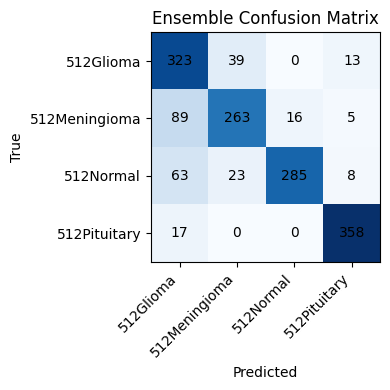

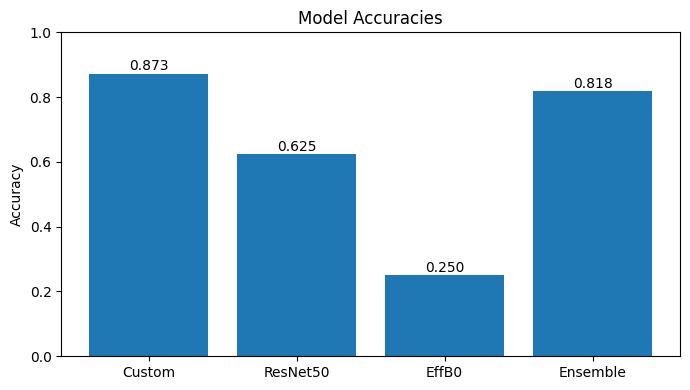

In [17]:
# ==== Predictions + Ensemble + Comparison ====
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import itertools

# Predict in streamed batches (tf.data already batched)
proba_custom = np.concatenate([cnn.predict(b[0], verbose=0) for b in test_gray])
proba_resnet = np.concatenate([resnet.predict(b[0], verbose=0) for b in test_rgb])
proba_eff    = np.concatenate([effnet.predict(b[0], verbose=0) for b in test_rgb])

# Average probs
proba_ens = (proba_custom + proba_resnet + proba_eff) / 3.0

y_true = np.concatenate([y for _, y in test_gray.as_numpy_iterator()])  # same order across streams

pred_custom = np.argmax(proba_custom, axis=1)
pred_resnet = np.argmax(proba_resnet, axis=1)
pred_eff    = np.argmax(proba_eff, axis=1)
pred_ens    = np.argmax(proba_ens, axis=1)

acc_custom = accuracy_score(y_true, pred_custom)
acc_resnet = accuracy_score(y_true, pred_resnet)
acc_eff    = accuracy_score(y_true, pred_eff)
acc_ens    = accuracy_score(y_true, pred_ens)

print("\n📊 Accuracies")
print(f"Custom CNN     : {acc_custom:.4f}")
print(f"ResNet50       : {acc_resnet:.4f}")
print(f"EfficientNetB0 : {acc_eff:.4f}")
print(f"Ensemble (avg) : {acc_ens:.4f}")

# Classification report (ensemble)
print("\n===== ENSEMBLE REPORT =====")
print(classification_report(y_true, pred_ens, target_names=class_names, digits=4))

# Confusion matrix (ensemble)
cm = confusion_matrix(y_true, pred_ens)
plt.figure(figsize=(1.2*len(class_names), 1.0*len(class_names)))
plt.imshow(cm, cmap='Blues')
plt.title("Ensemble Confusion Matrix")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.xticks(range(len(class_names)), class_names, rotation=45, ha='right')
plt.yticks(range(len(class_names)), class_names)
for (i, j) in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, cm[i, j], ha='center', va='center')
plt.tight_layout(); plt.show()

# Accuracy bar
labels = ["Custom", "ResNet50", "EffB0", "Ensemble"]
vals = [acc_custom, acc_resnet, acc_eff, acc_ens]
plt.figure(figsize=(7,4))
plt.bar(labels, vals)
for i, v in enumerate(vals):
    plt.text(i, v+0.01, f"{v:.3f}", ha='center')
plt.ylim(0, 1.0); plt.title("Model Accuracies"); plt.ylabel("Accuracy")
plt.tight_layout(); plt.show()


In [18]:
# Auto-weighted ensemble using validation performance
import numpy as np
from sklearn.metrics import accuracy_score

# 1) Get validation labels (same order for both streams)
y_val_true = np.concatenate([y for _, y in val_gray.as_numpy_iterator()])

# 2) Collect val probabilities
val_custom = np.concatenate([cnn.predict(x, verbose=0)      for x,_ in val_gray])
val_resnet = np.concatenate([resnet.predict(x, verbose=0)   for x,_ in val_rgb])

# Optional third model (EffB0 or MobileNetV2 or EfficientNetV2 if you trained one)
val_third = None
third_name = None
if 'effnet' in globals():
    val_third = np.concatenate([effnet.predict(x, verbose=0) for x,_ in val_rgb])
    third_name = "EffB0"
elif 'third_model' in globals():
    val_third = np.concatenate([third_model.predict(x, verbose=0) for x,_ in val_rgb])
    third_name = third_model.name

# 3) Compute per-model val accuracies
acc_c_val = accuracy_score(y_val_true, np.argmax(val_custom, axis=1))
acc_r_val = accuracy_score(y_val_true, np.argmax(val_resnet, axis=1))
weights = [acc_c_val, acc_r_val]

if val_third is not None:
    acc_t_val = accuracy_score(y_val_true, np.argmax(val_third, axis=1))
    # If the third model is weak, give it tiny weight (or set to 0 to drop)
    weights.append(max(acc_t_val, 1e-6))  # avoid zero in case all poor
else:
    acc_t_val = None

# 4) Normalize weights
weights = np.array(weights, dtype=np.float32)
weights = weights / weights.sum()

print(f"Validation accuracies -> Custom:{acc_c_val:.3f}, ResNet:{acc_r_val:.3f}" +
      (f", {third_name}:{acc_t_val:.3f}" if acc_t_val is not None else ""))
print("Learned weights:", weights)

# 5) Apply to TEST predictions
proba_custom = np.concatenate([cnn.predict(b[0], verbose=0)    for b in test_gray])
proba_resnet = np.concatenate([resnet.predict(b[0], verbose=0) for b in test_rgb])
parts = [proba_custom, proba_resnet]
if val_third is not None:
    proba_third = np.concatenate([ (effnet if 'effnet' in globals() else third_model).predict(b[0], verbose=0)
                                   for b in test_rgb ])
    parts.append(proba_third)

proba_weighted = np.zeros_like(parts[0])
for w, p in zip(weights, parts):
    proba_weighted += w * p

y_test_true = np.concatenate([y for _, y in test_gray.as_numpy_iterator()])
pred_weighted = np.argmax(proba_weighted, axis=1)
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
print(f"Auto-weighted ensemble accuracy: {accuracy_score(y_test_true, pred_weighted):.4f}")
print(classification_report(y_test_true, pred_weighted, target_names=class_names, digits=4))


Validation accuracies -> Custom:0.874, ResNet:0.621, EffB0:0.250
Learned weights: [0.5007153  0.35622317 0.1430615 ]
Auto-weighted ensemble accuracy: 0.8722
               precision    recall  f1-score   support

    512Glioma     0.8596    0.8000    0.8287       375
512Meningioma     0.7835    0.8633    0.8214       373
    512Normal     0.9518    0.8338    0.8889       379
 512Pituitary     0.9073    0.9920    0.9478       375

     accuracy                         0.8722      1502
    macro avg     0.8755    0.8723    0.8717      1502
 weighted avg     0.8759    0.8722    0.8718      1502



In [19]:
# Stacking meta-learner on validation, evaluate on test
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# 1) Build validation feature matrix from model probabilities
Xv_parts = [val_custom, val_resnet]
if 'val_third' in locals() and val_third is not None:
    Xv_parts.append(val_third)
X_val_stack = np.concatenate(Xv_parts, axis=1)  # [N_val, K * num_models]
y_val_stack = y_val_true

# 2) Train meta-learner (simple, robust)
meta = LogisticRegression(max_iter=200, multi_class='multinomial')
meta.fit(X_val_stack, y_val_stack)

# 3) Build TEST feature matrix the same way
Xt_parts = [proba_custom, proba_resnet]
if 'proba_third' in locals():
    Xt_parts.append(proba_third)
X_test_stack = np.concatenate(Xt_parts, axis=1)
y_test_true = np.concatenate([y for _, y in test_gray.as_numpy_iterator()])

# 4) Predict & report
pred_stack = meta.predict(X_test_stack)
print(f"Stacked hybrid accuracy: {accuracy_score(y_test_true, pred_stack):.4f}")
print(classification_report(y_test_true, pred_stack, target_names=class_names, digits=4))


Stacked hybrid accuracy: 0.8768
               precision    recall  f1-score   support

    512Glioma     0.8768    0.7973    0.8352       375
512Meningioma     0.7818    0.8740    0.8253       373
    512Normal     0.9496    0.8443    0.8939       379
 512Pituitary     0.9140    0.9920    0.9514       375

     accuracy                         0.8768      1502
    macro avg     0.8805    0.8769    0.8764      1502
 weighted avg     0.8809    0.8768    0.8766      1502



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


=== Individual Accuracies (TEST) ===
Custom      : 0.8728
ResNet50    : 0.6245
EffB0       : 0.2497
Average Ens.: 0.8182
Weighted Ens.: 0.8722
Stacked Hybrid: 0.8768

🟢 Best on TEST: Stacked  (acc=0.8768)

Classification report (BEST):
               precision    recall  f1-score   support

    512Glioma     0.8768    0.7973    0.8352       375
512Meningioma     0.7818    0.8740    0.8253       373
    512Normal     0.9496    0.8443    0.8939       379
 512Pituitary     0.9140    0.9920    0.9514       375

     accuracy                         0.8768      1502
    macro avg     0.8805    0.8769    0.8764      1502
 weighted avg     0.8809    0.8768    0.8766      1502



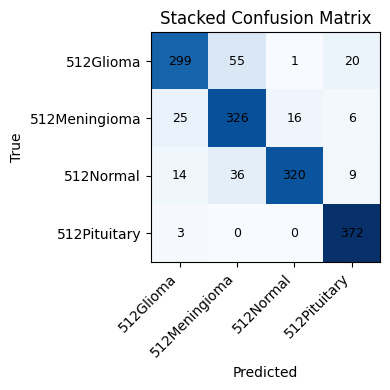

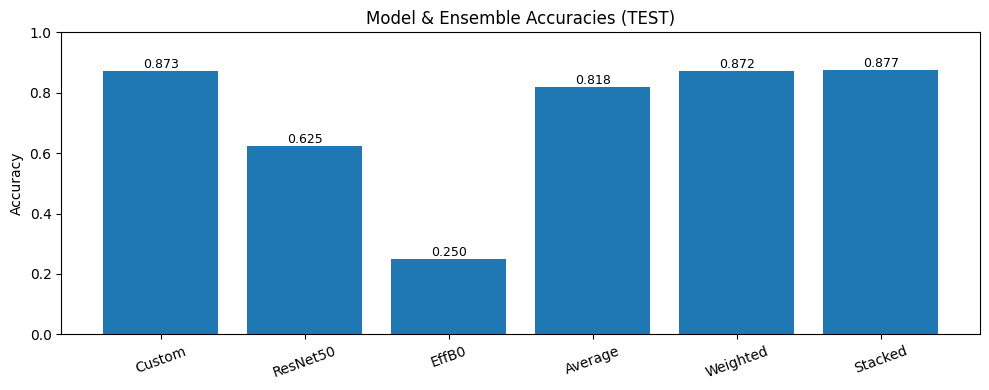

In [20]:
# ======= ONE-CELL: Compare single models, avg ensemble, auto-weighted, and stacked hybrid =======
import numpy as np, matplotlib.pyplot as plt, itertools, gc, warnings
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression

warnings.filterwarnings("ignore")

# --- Guards ---
assert 'cnn' in globals(), "Custom CNN (cnn) not found."
assert 'resnet' in globals(), "ResNet model (resnet) not found."
assert 'test_gray' in globals() and 'test_rgb' in globals(), "Need test_gray/test_rgb datasets."
assert 'val_gray' in globals() and 'val_rgb' in globals(), "Need val_gray/val_rgb for weighting/stacking."
assert 'class_names' in globals(), "Need class_names list."

# --- Detect third model if present ---
third_model = None
third_name  = None
if 'effnet' in globals():
    third_model, third_name = effnet, "EffB0"
elif 'third_model' in globals():
    third_model, third_name = third_model, third_model.name  # keep its own name

# --- Helpers to stream probabilities (low memory) ---
def stream_proba(model, ds):
    out = []
    for batch_x, _ in ds:
        out.append(model.predict(batch_x, verbose=0))
    return np.concatenate(out, axis=0)

def stream_labels(ds):
    return np.concatenate([y for _, y in ds.as_numpy_iterator()], axis=0)

# --- Test labels (from gray stream for canonical order) ---
y_test_true = stream_labels(test_gray)

# --- TEST probabilities for each model ---
proba_custom_test = stream_proba(cnn,    test_gray)
proba_resnet_test = stream_proba(resnet, test_rgb)
parts_test = [("Custom", proba_custom_test), ("ResNet50", proba_resnet_test)]

if third_model is not None:
    proba_third_test = stream_proba(third_model, test_rgb)
    parts_test.append((third_name, proba_third_test))

# --- Individual test accuracies ---
accs_single = {}
preds_single = {}
for name, proba in parts_test:
    pred = np.argmax(proba, axis=1)
    preds_single[name] = pred
    accs_single[name] = accuracy_score(y_test_true, pred)

# --- Average ensemble (across available models) ---
proba_avg = np.mean([p for _, p in parts_test], axis=0)
pred_avg  = np.argmax(proba_avg, axis=1)
acc_avg   = accuracy_score(y_test_true, pred_avg)

# --- Build VALIDATION probabilities for weighting & stacking ---
y_val_true       = stream_labels(val_gray)  # canonical order
proba_custom_val = stream_proba(cnn,    val_gray)
proba_resnet_val = stream_proba(resnet, val_rgb)
parts_val = [("Custom", proba_custom_val), ("ResNet50", proba_resnet_val)]
if third_model is not None:
    proba_third_val = stream_proba(third_model, val_rgb)
    parts_val.append((third_name, proba_third_val))

# --- Auto-weighted ensemble (weights from validation accuracies) ---
weights = []
for (name, proba) in parts_val:
    acc_v = accuracy_score(y_val_true, np.argmax(proba, axis=1))
    weights.append(acc_v)
weights = np.array(weights, dtype=np.float32)
weights = weights / (weights.sum() + 1e-8)

# apply weights on TEST
proba_weighted = np.zeros_like(parts_test[0][1])
for w, (_, p) in zip(weights, parts_test):
    proba_weighted += w * p
pred_weighted = np.argmax(proba_weighted, axis=1)
acc_weighted  = accuracy_score(y_test_true, pred_weighted)

# --- Stacked hybrid (LogReg on validation probs → test probs) ---
Xv = np.concatenate([p for _, p in parts_val], axis=1)
Xt = np.concatenate([p for _, p in parts_test], axis=1)

meta = LogisticRegression(max_iter=200, multi_class='multinomial')
meta.fit(Xv, y_val_true)
pred_stack = meta.predict(Xt)
acc_stack  = accuracy_score(y_test_true, pred_stack)

# --- Print reports (stacked and best variant) ---
print("=== Individual Accuracies (TEST) ===")
for k, v in accs_single.items():
    print(f"{k:12s}: {v:.4f}")
print(f"{'Average Ens.':12s}: {acc_avg:.4f}")
print(f"{'Weighted Ens.':12s}: {acc_weighted:.4f}")
print(f"{'Stacked Hybrid':12s}: {acc_stack:.4f}")

# Choose best for confusion/report
all_accs = dict(accs_single)
all_accs.update({"Average": acc_avg, "Weighted": acc_weighted, "Stacked": acc_stack})
best_name = max(all_accs, key=all_accs.get)
best_pred = (
    preds_single.get(best_name, None) if best_name in preds_single
    else (pred_avg if best_name=="Average" else pred_weighted if best_name=="Weighted" else pred_stack)
)

print(f"\n🟢 Best on TEST: {best_name}  (acc={all_accs[best_name]:.4f})")
print("\nClassification report (BEST):")
print(classification_report(y_test_true, best_pred, target_names=class_names, digits=4))

# --- Confusion matrix for BEST ---
cm = confusion_matrix(y_test_true, best_pred)
plt.figure(figsize=(1.2*len(class_names), 1.0*len(class_names)))
plt.imshow(cm, cmap='Blues')
plt.title(f"{best_name} Confusion Matrix")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.xticks(range(len(class_names)), class_names, rotation=45, ha='right')
plt.yticks(range(len(class_names)), class_names)
for (i, j) in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, cm[i, j], ha='center', va='center', fontsize=9)
plt.tight_layout(); plt.show()

# --- Accuracy bar chart (all variants) ---
labels = list(accs_single.keys()) + ["Average", "Weighted", "Stacked"]
values = [accs_single[k] for k in accs_single] + [acc_avg, acc_weighted, acc_stack]

plt.figure(figsize=(10,4))
plt.bar(labels, values)
plt.ylim(0, 1.0); plt.ylabel("Accuracy"); plt.title("Model & Ensemble Accuracies (TEST)")
for i, v in enumerate(values):
    plt.text(i, v + 0.01, f"{v:.3f}", ha='center', fontsize=9)
plt.xticks(rotation=20)
plt.tight_layout(); plt.show()

gc.collect();


In [23]:
# === Cell 1: MobileNetV3Large Training with aug, label smoothing, cosine LR, class weights ===
import tensorflow as tf, numpy as np, math, gc
from sklearn.utils.class_weight import compute_class_weight

tf.keras.backend.clear_session(); gc.collect()

# ---------------------------------------------------------
# 1) Data augmentation & label smoothing
# ---------------------------------------------------------
data_augment = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.08),
    tf.keras.layers.RandomZoom(0.10),
    tf.keras.layers.RandomTranslation(0.08, 0.08),
    tf.keras.layers.RandomContrast(0.1),
], name="data_augment")

label_smoothing = 0.05

# ---------------------------------------------------------
# 2) Build MobileNetV3Large backbone
# ---------------------------------------------------------
from tensorflow.keras.applications import MobileNetV3Large
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input as mbv3_pre
from tensorflow.keras.layers import Input, Lambda, GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.models import Model

inp = Input(shape=(IMG_SIZE_RGB, IMG_SIZE_RGB, 3), name="rgb_input")
x = data_augment(inp)
x = Lambda(mbv3_pre, name="mbv3_pre")(x)

base = MobileNetV3Large(weights="imagenet", include_top=False, input_tensor=x)
base.trainable = False  # freeze backbone first

x = base.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.35)(x)
out = Dense(num_classes, activation="softmax", name="head_out", dtype="float32")(x)
mbv3 = Model(inp, out, name="MobileNetV3Large_Baseline")

# ---------------------------------------------------------
# 3) Learning rate schedule (cosine + warmup)
# ---------------------------------------------------------
initial_lr = 3e-4
warmup_epochs = 2
total_epochs_stage1 = 10
total_epochs_stage2 = 12

def cosine_warmup(epoch: int) -> float:
    if epoch < warmup_epochs:
        lr = initial_lr * (epoch + 1) / warmup_epochs
    else:
        min_lr = 5e-5
        denom = max(1, (total_epochs_stage1 - warmup_epochs))
        progress = (epoch - warmup_epochs) / denom
        lr = min_lr + 0.5 * (initial_lr - min_lr) * (1.0 + math.cos(math.pi * progress))
    return float(lr)

lr_cb_stage1 = tf.keras.callbacks.LearningRateScheduler(cosine_warmup, verbose=0)

cbs_common = [
    tf.keras.callbacks.ModelCheckpoint(
        "/tmp/mbv3_stage_best.keras", monitor="val_accuracy",
        save_best_only=True, save_weights_only=False, verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=5,
                                     restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                         patience=2, min_lr=1e-6, verbose=1),
]

# ---------------------------------------------------------
# 4) One-hot encode labels for categorical loss
# ---------------------------------------------------------
from tensorflow.keras.utils import to_categorical

def one_hot_encode(ds, num_classes):
    return ds.map(lambda x, y: (x, tf.one_hot(y, num_classes)))

train_rgb_oh = one_hot_encode(train_rgb, num_classes)
val_rgb_oh   = one_hot_encode(val_rgb, num_classes)
test_rgb_oh  = one_hot_encode(test_rgb, num_classes)

# ---------------------------------------------------------
# 5) Class weights
# ---------------------------------------------------------
y_train_vec = np.concatenate([y for _, y in train_rgb.unbatch().batch(4096)])
classes = np.arange(num_classes)
class_w = compute_class_weight(class_weight="balanced", classes=classes, y=y_train_vec)
class_w = {i: float(w) for i, w in enumerate(class_w)}
print("Class weights:", class_w)

# ---------------------------------------------------------
# 6) Stage 1: train head only
# ---------------------------------------------------------
mbv3.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=initial_lr),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=label_smoothing),
    metrics=["accuracy"]
)

hist1 = mbv3.fit(
    train_rgb_oh, validation_data=val_rgb_oh,
    epochs=total_epochs_stage1,
    class_weight=class_w,
    callbacks=cbs_common + [lr_cb_stage1],
    verbose=1
)

# ---------------------------------------------------------
# 7) Stage 2: fine-tune last 30% of backbone
# ---------------------------------------------------------
n_total = len(base.layers)
for layer in base.layers[int(n_total*0.7):]:
    if not isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = True

mbv3.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=label_smoothing),
    metrics=["accuracy"]
)

hist2 = mbv3.fit(
    train_rgb_oh, validation_data=val_rgb_oh,
    epochs=total_epochs_stage2,
    class_weight=class_w,
    callbacks=cbs_common,
    verbose=1
)

# ---------------------------------------------------------
# 8) Final evaluation
# ---------------------------------------------------------
mbv3_eval = mbv3.evaluate(test_rgb_oh, verbose=0)
print(f"MobileNetV3Large — Test accuracy: {mbv3_eval[1]:.4f}")


Class weights: {0: 1.0018765638031693, 1: 1.0069153394803017, 2: 0.9894975288303131, 3: 1.0018765638031693}
Epoch 1/10
300/301 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.2350 - loss: 1.6911
Epoch 1: val_accuracy improved from None to 0.30116, saving model to /tmp/mbv3_stage_best.keras
301/301 ━━━━━━━━━━━━━━━━━━━━ 19s 39ms/step - accuracy: 0.2570 - loss: 1.5546 - val_accuracy: 0.3012 - val_loss: 1.3553 - learning_rate: 1.5000e-04
Epoch 2/10
298/301 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.2615 - loss: 1.4291
Epoch 2: val_accuracy improved from 0.30116 to 0.38602, saving model to /tmp/mbv3_stage_best.keras
301/301 ━━━━━━━━━━━━━━━━━━━━ 18s 31ms/step - accuracy: 0.2893 - loss: 1.4068 - val_accuracy: 0.3860 - val_loss: 1.3141 - learning_rate: 3.0000e-04
Epoch 3/10
300/301 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.3207 - loss: 1.3557
Epoch 3: val_accuracy improved from 0.38602 to 0.41847, saving model to /tmp/mbv3_stage_best.keras
301/301 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step -

In [24]:
# === TTA: average several augmented passes at inference ===
import numpy as np
from sklearn.metrics import accuracy_score, classification_report

def tta_predict(model, ds, n_aug=8):
    # Run model n times with augmentation ON by flipping the aug layer to training=True
    probas = []
    for _ in range(n_aug):
        out = []
        for batch_x, _ in ds:
            # Force augment layer to apply stochastic augments by calling the model in training mode
            out.append(model(batch_x, training=True).numpy())
        probas.append(np.concatenate(out, axis=0))
    return np.mean(probas, axis=0)

y_test_true = np.concatenate([y for _, y in test_rgb.as_numpy_iterator()])

proba_tta = tta_predict(mbv3, test_rgb, n_aug=8)
pred_tta = np.argmax(proba_tta, axis=1)
acc_tta = accuracy_score(y_test_true, pred_tta)
print(f"TTA accuracy (MobileNetV3Large): {acc_tta:.4f}")
print("\nTTA classification report:")
print(classification_report(y_test_true, pred_tta, target_names=class_names, digits=4))


TTA accuracy (MobileNetV3Large): 0.7403

TTA classification report:
               precision    recall  f1-score   support

    512Glioma     0.7413    0.5120    0.6057       375
512Meningioma     0.7435    0.6917    0.7167       373
    512Normal     0.8305    0.8918    0.8601       379
 512Pituitary     0.6626    0.8640    0.7500       375

     accuracy                         0.7403      1502
    macro avg     0.7445    0.7399    0.7331      1502
 weighted avg     0.7447    0.7403    0.7335      1502



=== Individual Accuracies (TEST) ===
Custom            : 0.8728
ResNet50          : 0.6245
MobileNetV3Large  : 0.6711
Average Ens.      : 0.8762
Weighted Ens.     : 0.8815
Stacked Hybrid    : 0.8828

🟢 Best on TEST: Stacked  (acc=0.8828)

Classification report (BEST):
               precision    recall  f1-score   support

    512Glioma     0.8791    0.7947    0.8347       375
512Meningioma     0.7923    0.8794    0.8335       373
    512Normal     0.9535    0.8654    0.9073       379
 512Pituitary     0.9185    0.9920    0.9538       375

     accuracy                         0.8828      1502
    macro avg     0.8858    0.8829    0.8824      1502
 weighted avg     0.8861    0.8828    0.8825      1502



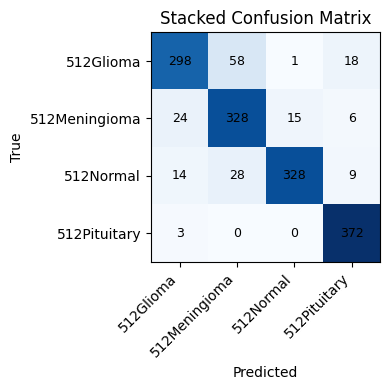

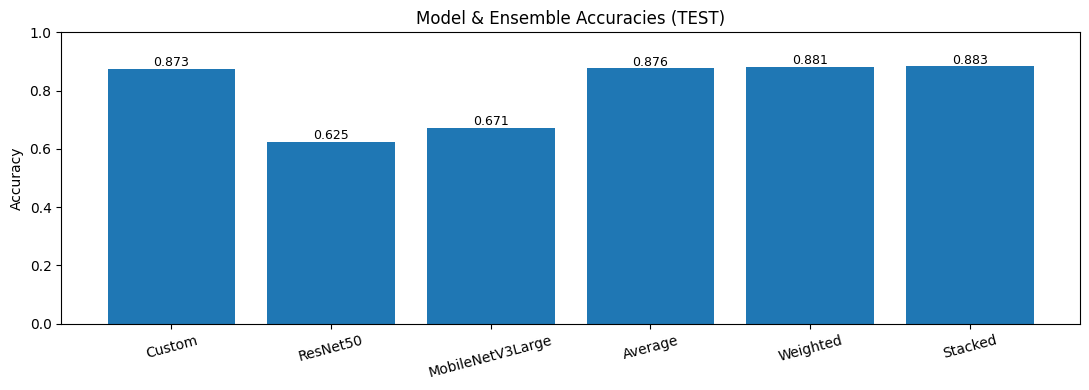

In [25]:
# ======= Compare Custom, ResNet50, MobileNetV3Large + Avg / Weighted / Stacked =======
import numpy as np, matplotlib.pyplot as plt, itertools, gc, warnings
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression

warnings.filterwarnings("ignore")

# --- Guards (datasets) ---
assert 'test_gray' in globals() and 'test_rgb' in globals(), "Need test_gray/test_rgb."
assert 'val_gray' in globals() and 'val_rgb' in globals(),   "Need val_gray/val_rgb."
assert 'class_names' in globals(), "Need class_names."

# --- Optional models (present or not) ---
models = []  # (name, model, ds_for_inference)
if 'cnn' in globals():
    models.append(("Custom", cnn,  test_gray))
if 'resnet' in globals():
    models.append(("ResNet50", resnet, test_rgb))
if 'mbv3' in globals():
    models.append(("MobileNetV3Large", mbv3, test_rgb))

if not models:
    raise RuntimeError("No models found. Expected any of: cnn, resnet, mbv3.")

# --- Helper: stream predictions and labels (low memory) ---
def stream_proba(model, ds):
    out = []
    for batch_x, _ in ds:
        out.append(model.predict(batch_x, verbose=0))
    return np.concatenate(out, axis=0)

def stream_labels(ds):
    return np.concatenate([y for _, y in ds.as_numpy_iterator()], axis=0)

# Canonical TEST labels (from gray pipeline)
y_test_true = stream_labels(test_gray)

# --- TEST probs per model ---
parts_test = []   # list of (name, proba)
for name, model, ds in models:
    parts_test.append((name, stream_proba(model, ds)))

# --- Individual accuracies ---
accs_single, preds_single = {}, {}
for name, proba in parts_test:
    pred = np.argmax(proba, axis=1)
    preds_single[name] = pred
    accs_single[name] = accuracy_score(y_test_true, pred)

# --- Average ensemble ---
proba_avg = np.mean([p for _, p in parts_test], axis=0)
pred_avg  = np.argmax(proba_avg, axis=1)
acc_avg   = accuracy_score(y_test_true, pred_avg)

# --- VALIDATION probs for weighting/stacking ---
y_val_true = stream_labels(val_gray)
parts_val = []
for name, model, ds in models:
    # use matching val ds: gray for Custom, rgb for others
    vds = val_gray if ("Custom" in name) else val_rgb
    parts_val.append((name, stream_proba(model, vds)))

# --- Auto-weighted ensemble (weights from val accuracies) ---
weights = []
for name, proba in parts_val:
    acc_v = accuracy_score(y_val_true, np.argmax(proba, axis=1))
    weights.append(acc_v)
weights = np.array(weights, dtype=np.float32)
weights = weights / (weights.sum() + 1e-8)

proba_weighted = np.zeros_like(parts_test[0][1])
for w, (_, p) in zip(weights, parts_test):
    proba_weighted += w * p
pred_weighted = np.argmax(proba_weighted, axis=1)
acc_weighted  = accuracy_score(y_test_true, pred_weighted)

# --- Stacked hybrid (LogReg on val -> test) ---
Xv = np.concatenate([p for _, p in parts_val], axis=1)
Xt = np.concatenate([p for _, p in parts_test], axis=1)
meta = LogisticRegression(max_iter=200, multi_class='multinomial')
meta.fit(Xv, y_val_true)
pred_stack = meta.predict(Xt)
acc_stack  = accuracy_score(y_test_true, pred_stack)

# --- Print summaries ---
print("=== Individual Accuracies (TEST) ===")
for k, v in accs_single.items():
    print(f"{k:18s}: {v:.4f}")
print(f"{'Average Ens.':18s}: {acc_avg:.4f}")
print(f"{'Weighted Ens.':18s}: {acc_weighted:.4f}")
print(f"{'Stacked Hybrid':18s}: {acc_stack:.4f}")

# --- Show classification report & confusion matrix for BEST ---
all_accs = dict(accs_single)
all_accs.update({"Average": acc_avg, "Weighted": acc_weighted, "Stacked": acc_stack})
best_name = max(all_accs, key=all_accs.get)

if best_name in preds_single:
    best_pred = preds_single[best_name]
elif best_name == "Average":
    best_pred = pred_avg
elif best_name == "Weighted":
    best_pred = pred_weighted
else:
    best_pred = pred_stack

print(f"\n🟢 Best on TEST: {best_name}  (acc={all_accs[best_name]:.4f})\n")
print("Classification report (BEST):")
print(classification_report(y_test_true, best_pred, target_names=class_names, digits=4))

# --- Confusion matrix (BEST) ---
cm = confusion_matrix(y_test_true, best_pred)
plt.figure(figsize=(1.2*len(class_names), 1.0*len(class_names)))
plt.imshow(cm, cmap='Blues')
plt.title(f"{best_name} Confusion Matrix")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.xticks(range(len(class_names)), class_names, rotation=45, ha='right')
plt.yticks(range(len(class_names)), class_names)
for (i, j) in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, cm[i, j], ha='center', va='center', fontsize=9)
plt.tight_layout(); plt.show()

# --- Accuracy bar chart (all variants) ---
labels = list(accs_single.keys()) + ["Average", "Weighted", "Stacked"]
values = [accs_single[k] for k in accs_single] + [acc_avg, acc_weighted, acc_stack]

plt.figure(figsize=(11,4))
plt.bar(labels, values)
plt.ylim(0, 1.0); plt.ylabel("Accuracy"); plt.title("Model & Ensemble Accuracies (TEST)")
for i, v in enumerate(values):
    plt.text(i, v + 0.01, f"{v:.3f}", ha='center', fontsize=9)
plt.xticks(rotation=15)
plt.tight_layout(); plt.show()

gc.collect();


In [32]:
# Inspect CNN architecture and layers
print("=== CNN Summary ===")
cnn.summary()

print("\n=== Layer index, name, output shape ===")
for i, layer in enumerate(cnn.layers):
    try:
        print(f"{i:2d} | {layer.name:25s} | {layer.output_shape}")
    except:
        print(f"{i:2d} | {layer.name:25s} | (no shape info)")


=== CNN Summary ===


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,551,246 (74.58 MB)

 Trainable params: 6,516,932 (24.86 MB)

 Non-trainable params: 448 (1.75 KB)

 Optimizer params: 13,033,866 (49.72 MB)


=== Layer index, name, output shape ===
 0 | conv2d                    | (no shape info)
 1 | batch_normalization       | (no shape info)
 2 | max_pooling2d             | (no shape info)
 3 | conv2d_1                  | (no shape info)
 4 | batch_normalization_1     | (no shape info)
 5 | max_pooling2d_1           | (no shape info)
 6 | conv2d_2                  | (no shape info)
 7 | batch_normalization_2     | (no shape info)
 8 | max_pooling2d_2           | (no shape info)
 9 | flatten                   | (no shape info)
10 | dense                     | (no shape info)
11 | dropout                   | (no shape info)
12 | dense_1                   | (no shape info)


In [34]:
# If X_train_dl exists, use it
_ = cnn.predict(X_train_cnn[:1], verbose=0)
print("Model built:", cnn.input_shape)


NameError: name 'X_train_cnn' is not defined

In [35]:
# Cell 1: Build CNN feature extractor from last hidden Dense (index 10)
import tensorflow as tf
from tensorflow.keras import Model

# If the model hasn't been "built" yet (no .input), we can still wire via layers
feature_extractor = Model(
    inputs=cnn.layers[0].input,    # first layer input of your Sequential CNN
    outputs=cnn.layers[10].output  # Dense(256) layer from your summary
)
feature_extractor.trainable = False
print("✅ Feature extractor:", feature_extractor.output_shape)


✅ Feature extractor: (None, 256)


In [36]:
# Cell 2: Create embeddings for train/val/test from tf.data pipelines
import numpy as np

# class names
if 'le' in globals() and hasattr(le, 'classes_'):
    class_names = list(le.classes_)
    num_classes = len(class_names)
else:
    y_tmp = np.concatenate([y for _, y in test_gray.as_numpy_iterator()])
    num_classes = int(y_tmp.max()) + 1
    class_names = [f"Class {i}" for i in range(num_classes)]

def embed_ds(ds, model):
    feats, labels = [], []
    for batch_x, batch_y in ds:
        feats.append(model.predict(batch_x, verbose=0))
        labels.append(batch_y.numpy())
    return np.concatenate(feats, axis=0), np.concatenate(labels, axis=0)

X_train_feat, y_train = embed_ds(train_gray, feature_extractor)
X_val_feat,   y_val   = embed_ds(val_gray,   feature_extractor)
X_test_feat,  y_test  = embed_ds(test_gray,  feature_extractor)

print("Embeddings:")
print("  Train:", X_train_feat.shape, " Val:", X_val_feat.shape, " Test:", X_test_feat.shape)
print("Classes:", class_names)


Embeddings:
  Train: (4805, 256)  Val: (1202, 256)  Test: (1502, 256)
Classes: [np.str_('512Glioma'), np.str_('512Meningioma'), np.str_('512Normal'), np.str_('512Pituitary')]


In [38]:
# Cell 3: XGBoost on CNN embeddings
import sys, subprocess, numpy as np
from sklearn.metrics import accuracy_score, classification_report

try:
    import xgboost as xgb
except Exception:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "xgboost"])
    import xgboost as xgb

# Use train+val for strongest meta-learner
X_trv = np.vstack([X_train_feat, X_val_feat])
y_trv = np.hstack([y_train, y_val])

xgb_clf = xgb.XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    objective="multi:softprob",
    num_class=len(class_names),
    eval_metric="mlogloss",
    random_state=42,
    tree_method="hist"  # fast, memory-friendly
)
xgb_clf.fit(X_trv, y_trv)

y_pred_xgb = xgb_clf.predict(X_test_feat)
acc_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"🎯 XGBoost-on-CNN accuracy: {acc_xgb:.4f}")
print(classification_report(y_test, y_pred_xgb, target_names=class_names, digits=4))

# Stash for comparison cell
XGB_STORE = {"pred": y_pred_xgb, "acc": acc_xgb}


🎯 XGBoost-on-CNN accuracy: 0.8802
               precision    recall  f1-score   support

    512Glioma     0.8551    0.8027    0.8281       375
512Meningioma     0.8005    0.8499    0.8244       373
    512Normal     0.9237    0.8945    0.9088       379
 512Pituitary     0.9432    0.9733    0.9580       375

     accuracy                         0.8802      1502
    macro avg     0.8806    0.8801    0.8798      1502
 weighted avg     0.8808    0.8802    0.8800      1502



In [39]:
# Cell 4: SVM(RBF) on CNN embeddings
import numpy as np
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

X_trv = np.vstack([X_train_feat, X_val_feat])
y_trv = np.hstack([y_train, y_val])

svm_clf = make_pipeline(
    StandardScaler(with_mean=True),
    SVC(kernel="rbf", C=5.0, gamma="scale", probability=False, random_state=42)
)
svm_clf.fit(X_trv, y_trv)

y_pred_svm = svm_clf.predict(X_test_feat)
acc_svm = accuracy_score(y_test, y_pred_svm)
print(f"🎯 SVM(RBF)-on-CNN accuracy: {acc_svm:.4f}")
print(classification_report(y_test, y_pred_svm, target_names=class_names, digits=4))

# Stash for comparison cell
SVM_STORE = {"pred": y_pred_svm, "acc": acc_svm}


🎯 SVM(RBF)-on-CNN accuracy: 0.8775
               precision    recall  f1-score   support

    512Glioma     0.8674    0.8027    0.8338       375
512Meningioma     0.8015    0.8660    0.8325       373
    512Normal     0.9071    0.8760    0.8913       379
 512Pituitary     0.9378    0.9653    0.9514       375

     accuracy                         0.8775      1502
    macro avg     0.8785    0.8775    0.8772      1502
 weighted avg     0.8786    0.8775    0.8773      1502



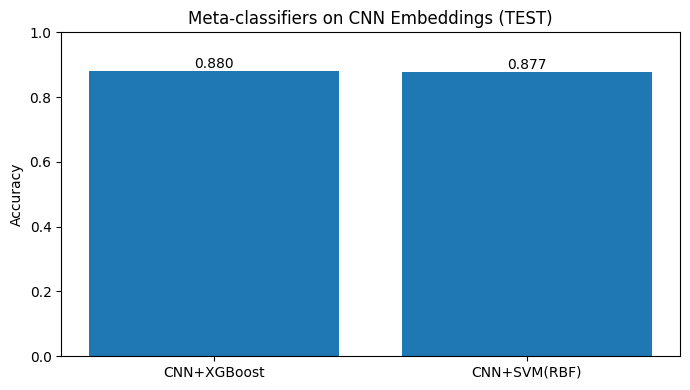

🟢 Best: CNN+XGBoost  (acc=0.8802)


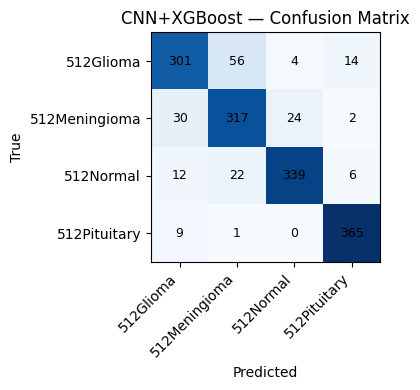

In [40]:
# Cell 5: Compare XGBoost vs SVM on CNN features (bar + confusion matrix)
import numpy as np, matplotlib.pyplot as plt, itertools
from sklearn.metrics import confusion_matrix

results = []
if 'XGB_STORE' in globals():
    results.append(("CNN+XGBoost", XGB_STORE["acc"], XGB_STORE["pred"]))
if 'SVM_STORE' in globals():
    results.append(("CNN+SVM(RBF)", SVM_STORE["acc"], SVM_STORE["pred"]))

if not results:
    raise RuntimeError("No results found. Run Cells 3 and/or 4 first.")

# Bar chart
labels = [r[0] for r in results]
accs   = [r[1] for r in results]
plt.figure(figsize=(7,4))
plt.bar(labels, accs)
for i, v in enumerate(accs):
    plt.text(i, v + 0.01, f"{v:.3f}", ha='center')
plt.ylim(0, 1.0)
plt.ylabel("Accuracy")
plt.title("Meta-classifiers on CNN Embeddings (TEST)")
plt.tight_layout(); plt.show()

# Confusion matrix for the best performer
best_idx = int(np.argmax(accs))
best_name, best_acc, best_pred = results[best_idx]
print(f"🟢 Best: {best_name}  (acc={best_acc:.4f})")

cm = confusion_matrix(y_test, best_pred)
plt.figure(figsize=(1.2*len(class_names), 1.0*len(class_names)))
plt.imshow(cm, cmap='Blues')
plt.title(f"{best_name} — Confusion Matrix")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.xticks(range(len(class_names)), class_names, rotation=45, ha='right')
plt.yticks(range(len(class_names)), class_names)
for (i, j) in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, cm[i, j], ha='center', va='center', fontsize=9)
plt.tight_layout(); plt.show()


In [41]:
# Rich CNN feature extractor: Dense(256) + GAP over last conv block => 384-D features
import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import GlobalAveragePooling2D

# Your layer indices by summary:
#  8 = max_pooling2d_2  (output ~ 14x14x128)
# 10 = dense (last hidden, 256)

# Branch A: last hidden dense(256)
feat_dense = cnn.layers[10].output  # (None, 256)

# Branch B: GAP from last conv block (take output BEFORE flatten -> layer 8 output)
conv_feat_map = cnn.layers[8].output   # (None, 14, 14, 128)
gap128 = GlobalAveragePooling2D(name="gap_from_conv")(conv_feat_map)  # (None, 128)

# Build two-head extractor (returns a list [dense256, gap128])
feature_extractor_rich = Model(
    inputs=cnn.layers[0].input,
    outputs=[feat_dense, gap128]
)
feature_extractor_rich.trainable = False
print("✅ Rich extractor ready: Dense256 + GAP128")


✅ Rich extractor ready: Dense256 + GAP128


In [42]:
# Stream embeddings (low RAM): concatenate Dense(256) and GAP(128) -> 384-D
import numpy as np

# class names
if 'le' in globals() and hasattr(le, 'classes_'):
    class_names = list(le.classes_)
else:
    class_names = [f"Class {i}" for i in range(int(np.max([y for _, y in test_gray.as_numpy_iterator()])) + 1)]

def embed_ds_rich(ds, model):
    f_list, y_list = [], []
    for xb, yb in ds:
        f_dense, f_gap = model.predict(xb, verbose=0)
        f = np.concatenate([f_dense, f_gap], axis=1)   # (N, 384)
        f_list.append(f)
        y_list.append(yb.numpy())
    return np.concatenate(f_list, axis=0), np.concatenate(y_list, axis=0)

X_train_feat, y_train = embed_ds_rich(train_gray, feature_extractor_rich)
X_val_feat,   y_val   = embed_ds_rich(val_gray,   feature_extractor_rich)
X_test_feat,  y_test  = embed_ds_rich(test_gray,  feature_extractor_rich)

print("Features:", X_train_feat.shape, X_val_feat.shape, X_test_feat.shape)
print("Classes:", class_names)


Features: (4805, 384) (1202, 384) (1502, 384)
Classes: [np.str_('512Glioma'), np.str_('512Meningioma'), np.str_('512Normal'), np.str_('512Pituitary')]


In [43]:
# Hyperparameter search for XGBoost with early stopping on validation
import sys, subprocess, numpy as np
from sklearn.metrics import accuracy_score
from collections import namedtuple

try:
    import xgboost as xgb
except Exception:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "xgboost"])
    import xgboost as xgb

# Class weights → per-sample weights for multi-class imbalance
# (inverse frequency)
counts = np.bincount(y_train, minlength=len(class_names))
freq = counts / counts.sum()
inv = 1.0 / np.maximum(freq, 1e-8)
inv = inv / inv.mean()  # normalize
w_train = inv[y_train]

# Candidate space (Colab-safe size). Tweak n_iter up if you have time.
import itertools, random
random.seed(42)

space = {
    "max_depth":        [4, 5, 6, 7, 8],
    "learning_rate":    [0.03, 0.05, 0.07, 0.1],
    "min_child_weight": [1, 2, 3, 5],
    "subsample":        [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "reg_alpha":        [0.0, 0.5, 1.0],
    "reg_lambda":       [1.0, 1.5, 2.0],
    "gamma":            [0.0, 0.1, 0.2],
}
# Random sampler over grid
def sample_params(k=20):
    keys = list(space.keys())
    for _ in range(k):
        yield {k: random.choice(space[k]) for k in keys}

Record = namedtuple("Record", ["params", "val_acc", "best_ntrees"])
records = []

dtrain = xgb.DMatrix(X_train_feat, label=y_train, weight=w_train)
dval   = xgb.DMatrix(X_val_feat,   label=y_val)

for i, params in enumerate(sample_params(k=25), 1):
    full_params = dict(
        objective="multi:softprob",
        num_class=len(class_names),
        eval_metric="mlogloss",
        tree_method="hist",
        random_state=42,
        **params
    )
    # Use a reasonably high n_estimators and let early stopping pick best
    evallist = [(dval, "val")]
    bst = xgb.train(
        full_params, dtrain,
        num_boost_round=1200,
        evals=evallist,
        early_stopping_rounds=60,
        verbose_eval=False
    )
    # Evaluate accuracy on val
    val_pred = np.argmax(bst.predict(dval, iteration_range=(0, bst.best_iteration+1)), axis=1)
    val_acc  = accuracy_score(y_val, val_pred)
    records.append(Record(full_params, val_acc, bst.best_iteration+1))
    print(f"[{i:02d}] val_acc={val_acc:.4f}  best_trees={bst.best_iteration+1}  params={params}")

# Pick best by val accuracy
best = max(records, key=lambda r: r.val_acc)
print("\n🏆 Best (val):", best.val_acc, "with trees:", best.best_ntrees)
print(best.params)

# Refit on train+val with best params and best_ntrees
X_tv = np.vstack([X_train_feat, X_val_feat])
y_tv = np.hstack([y_train, y_val])
w_tv = inv[y_tv]  # reuse class weights
dtv = xgb.DMatrix(X_tv, label=y_tv, weight=w_tv)
dte = xgb.DMatrix(X_test_feat, label=y_test)

bst_final = xgb.train(
    best.params, dtv,
    num_boost_round=best.best_ntrees,
    evals=[(dtv, "train")],
    verbose_eval=False
)

test_pred = np.argmax(bst_final.predict(dte), axis=1)
acc_test  = accuracy_score(y_test, test_pred)
print(f"\n🎯 Tuned XGB (refit train+val) — TEST accuracy: {acc_test:.4f}")

# Store for viz
XGB_TUNED = {
    "pred": test_pred,
    "proba": bst_final.predict(dte),
    "acc": acc_test,
    "params": best.params,
    "ntrees": best.best_ntrees
}


[01] val_acc=0.8819  best_trees=122  params={'max_depth': 4, 'learning_rate': 0.03, 'min_child_weight': 3, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_alpha': 0.0, 'reg_lambda': 2.0, 'gamma': 0.0}
[02] val_acc=0.8844  best_trees=121  params={'max_depth': 8, 'learning_rate': 0.03, 'min_child_weight': 5, 'subsample': 0.7, 'colsample_bytree': 0.7, 'reg_alpha': 0.0, 'reg_lambda': 1.0, 'gamma': 0.0}
[03] val_acc=0.8869  best_trees=114  params={'max_depth': 8, 'learning_rate': 0.03, 'min_child_weight': 2, 'subsample': 1.0, 'colsample_bytree': 0.8, 'reg_alpha': 0.5, 'reg_lambda': 2.0, 'gamma': 0.1}
[04] val_acc=0.8810  best_trees=73  params={'max_depth': 4, 'learning_rate': 0.05, 'min_child_weight': 5, 'subsample': 0.9, 'colsample_bytree': 0.9, 'reg_alpha': 0.0, 'reg_lambda': 1.0, 'gamma': 0.1}
[05] val_acc=0.8802  best_trees=135  params={'max_depth': 4, 'learning_rate': 0.03, 'min_child_weight': 5, 'subsample': 0.7, 'colsample_bytree': 0.9, 'reg_alpha': 0.5, 'reg_lambda': 2.0, 'gamma': 0

In [44]:
# Quick SVM tuning (small grid) on val, then refit on train+val
import numpy as np
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

grid = [(c,g) for c in [1.0, 2.0, 5.0, 10.0] for g in ["scale", 0.01, 0.001]]
best_acc, best_pair = -1.0, None

for C, gamma in grid:
    clf = make_pipeline(StandardScaler(with_mean=True), SVC(kernel="rbf", C=C, gamma=gamma))
    clf.fit(X_train_feat, y_train)
    val_acc = accuracy_score(y_val, clf.predict(X_val_feat))
    if val_acc > best_acc:
        best_acc, best_pair = val_acc, (C, gamma)
    print(f"SVM val_acc={val_acc:.4f}  C={C}  gamma={gamma}")

C_best, g_best = best_pair
svm_best = make_pipeline(StandardScaler(with_mean=True), SVC(kernel="rbf", C=C_best, gamma=g_best))
svm_best.fit(np.vstack([X_train_feat, X_val_feat]), np.hstack([y_train, y_val]))
svm_pred = svm_best.predict(X_test_feat)
svm_acc  = accuracy_score(y_test, svm_pred)
print(f"\n🎯 Tuned SVM — TEST accuracy: {svm_acc:.4f} (C={C_best}, gamma={g_best})")

SVM_TUNED = {"pred": svm_pred, "acc": svm_acc}


SVM val_acc=0.8968  C=1.0  gamma=scale
SVM val_acc=0.8952  C=1.0  gamma=0.01
SVM val_acc=0.8952  C=1.0  gamma=0.001
SVM val_acc=0.8968  C=2.0  gamma=scale
SVM val_acc=0.8985  C=2.0  gamma=0.01
SVM val_acc=0.8960  C=2.0  gamma=0.001
SVM val_acc=0.8943  C=5.0  gamma=scale
SVM val_acc=0.8952  C=5.0  gamma=0.01
SVM val_acc=0.8935  C=5.0  gamma=0.001
SVM val_acc=0.8935  C=10.0  gamma=scale
SVM val_acc=0.8960  C=10.0  gamma=0.01
SVM val_acc=0.8910  C=10.0  gamma=0.001

🎯 Tuned SVM — TEST accuracy: 0.9121 (C=2.0, gamma=0.01)


In [45]:
# Learn blend weight on VAL: alpha * XGB + (1-alpha) * CNN-softmax
import numpy as np
from sklearn.metrics import accuracy_score

# Get CNN softmax probs on val/test (from cnn model directly)
def stream_proba(model, ds):
    out = []
    for xb, _ in ds:
        out.append(model.predict(xb, verbose=0))
    return np.concatenate(out, axis=0)

proba_cnn_val  = stream_proba(cnn,  val_gray)
proba_cnn_test = stream_proba(cnn,  test_gray)

# XGB tuned probs come from previous cell
# Need val probs for XGB as well:
dval = xgb.DMatrix(X_val_feat)
proba_xgb_val = bst_final.predict(xgb.DMatrix(np.vstack([X_train_feat, X_val_feat])))[-len(X_val_feat):] \
                if 'bst_final' in globals() else None  # fallback if refit happened
proba_xgb_val = bst_final.predict(xgb.DMatrix(X_val_feat))
proba_xgb_test = XGB_TUNED["proba"]

# Search alpha in [0..1]
alphas = np.linspace(0, 1, 21)
best_alpha, best_val_acc = 0.0, -1.0
y_val_true = y_val

for a in alphas:
    mix_val = a*proba_xgb_val + (1-a)*proba_cnn_val
    acc = accuracy_score(y_val_true, np.argmax(mix_val, axis=1))
    if acc > best_val_acc:
        best_val_acc, best_alpha = acc, a

mix_test = best_alpha*proba_xgb_test + (1-best_alpha)*proba_cnn_test
blend_pred = np.argmax(mix_test, axis=1)
blend_acc  = accuracy_score(y_test, blend_pred)
print(f"🤝 CNN+XGB blend — best α={best_alpha:.2f}  TEST acc={blend_acc:.4f}")

BLEND = {"pred": blend_pred, "acc": blend_acc, "alpha": best_alpha}


🤝 CNN+XGB blend — best α=1.00  TEST acc=0.8908


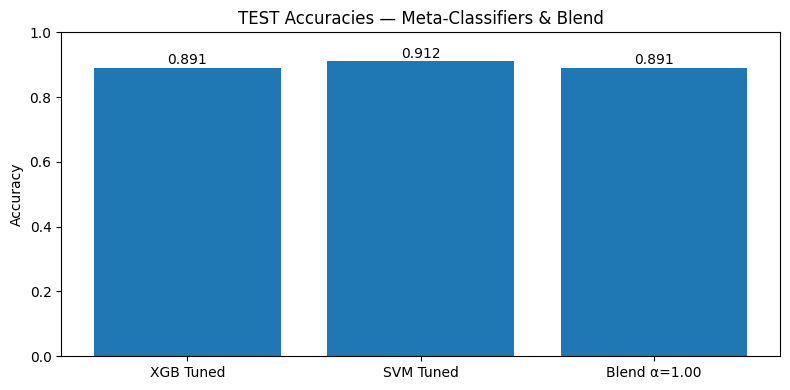

🟢 Best: SVM Tuned  (acc=0.9121)

Classification report:
               precision    recall  f1-score   support

    512Glioma     0.9177    0.8027    0.8563       375
512Meningioma     0.8536    0.9223    0.8866       373
    512Normal     0.9256    0.9525    0.9389       379
 512Pituitary     0.9554    0.9707    0.9630       375

     accuracy                         0.9121      1502
    macro avg     0.9131    0.9120    0.9112      1502
 weighted avg     0.9132    0.9121    0.9113      1502



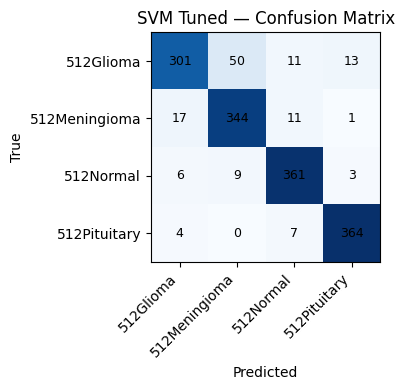

In [46]:
# Compare tuned XGB, tuned SVM (if run), and blended CNN+XGB
import numpy as np, matplotlib.pyplot as plt, itertools
from sklearn.metrics import confusion_matrix, classification_report

results = []
results.append(("XGB Tuned", XGB_TUNED["acc"], XGB_TUNED["pred"]))
if 'SVM_TUNED' in globals():
    results.append(("SVM Tuned", SVM_TUNED["acc"], SVM_TUNED["pred"]))
if 'BLEND' in globals():
    results.append((f"Blend α={BLEND['alpha']:.2f}", BLEND["acc"], BLEND["pred"]))

labels = [r[0] for r in results]
accs   = [r[1] for r in results]

plt.figure(figsize=(8,4))
plt.bar(labels, accs)
for i, v in enumerate(accs):
    plt.text(i, v+0.01, f"{v:.3f}", ha='center')
plt.ylim(0, 1.0); plt.ylabel("Accuracy"); plt.title("TEST Accuracies — Meta-Classifiers & Blend")
plt.tight_layout(); plt.show()

# Report & confusion matrix for best performer
best_i = int(np.argmax(accs))
best_name, best_acc, best_pred = results[best_i]
print(f"🟢 Best: {best_name}  (acc={best_acc:.4f})")
print("\nClassification report:")
print(classification_report(y_test, best_pred, target_names=class_names, digits=4))

cm = confusion_matrix(y_test, best_pred)
plt.figure(figsize=(1.2*len(class_names), 1.0*len(class_names)))
plt.imshow(cm, cmap='Blues')
plt.title(f"{best_name} — Confusion Matrix")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.xticks(range(len(class_names)), class_names, rotation=45, ha='right')
plt.yticks(range(len(class_names)), class_names)
for (i, j) in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, cm[i, j], ha='center', va='center', fontsize=9)
plt.tight_layout(); plt.show()


In [49]:
# === Install required packages ===
!pip install -q xgboost lightgbm catboost scikit-learn imagehash


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 14.1 MB/s eta 0:00:00


In [50]:
# Cell A: Detect near-duplicates across splits (perceptual hash)
# Works with your existing tf.data datasets: train_gray, val_gray, test_gray

import numpy as np, tensorflow as tf, os, io
from PIL import Image
import imagehash

def to_phash_batch(batch_x):
    hashes = []
    for i in range(batch_x.shape[0]):
        arr = (batch_x[i].numpy().squeeze()*255).astype("uint8")
        img = Image.fromarray(arr)
        hashes.append(str(imagehash.phash(img)))
    return hashes

def collect_hashes(ds, tag):
    hset, all_hashes = set(), []
    for bx, by in ds:
        hs = to_phash_batch(bx)
        all_hashes.extend([(h, int(y), tag) for h, y in zip(hs, by.numpy())])
        hset.update(hs)
    return hset, all_hashes

h_train, train_items = collect_hashes(train_gray, "train")
h_val,   val_items   = collect_hashes(val_gray,   "val")
h_test,  test_items  = collect_hashes(test_gray,  "test")

leak_train_test = h_train.intersection(h_test)
leak_val_test   = h_val.intersection(h_test)
leak_train_val  = h_train.intersection(h_val)

print(f"Duplicates train↔test: {len(leak_train_test)}")
print(f"Duplicates val↔test  : {len(leak_val_test)}")
print(f"Duplicates train↔val : {len(leak_train_val)}")


Duplicates train↔test: 7
Duplicates val↔test  : 14
Duplicates train↔val : 11


In [51]:
# Cell B1: Rich CNN feature extractor (Dense256 + GAP over last conv block)
import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import GlobalAveragePooling2D

# Your summary shows: layer 10 = Dense(256), layer 8 output = (None, 14,14,128)
feat_dense = cnn.layers[10].output           # (None, 256)
gap128     = GlobalAveragePooling2D()(cnn.layers[8].output)  # (None, 128)

feature_extractor_rich = Model(inputs=cnn.layers[0].input, outputs=[feat_dense, gap128])
feature_extractor_rich.trainable = False
print("✅ Rich extractor ready.")


✅ Rich extractor ready.


In [52]:
# Cell B2: Build a single TRAINVAL set (train_gray + val_gray) and TEST features
import numpy as np

def embed_ds_rich(ds, model):
    F, Y = [], []
    for xb, yb in ds:
        f1, f2 = model.predict(xb, verbose=0)
        F.append(np.concatenate([f1, f2], axis=1))  # (N, 384)
        Y.append(yb.numpy())
    return np.concatenate(F, 0), np.concatenate(Y, 0)

trainval_ds = train_gray.concatenate(val_gray)
X_tv, y_tv  = embed_ds_rich(trainval_ds, feature_extractor_rich)
X_te, y_te  = embed_ds_rich(test_gray,   feature_extractor_rich)

print("Train+Val:", X_tv.shape, " Test:", X_te.shape)


Train+Val: (6007, 384)  Test: (1502, 384)


In [53]:
# Cell B3: OOF stacking — generate out-of-fold predictions for SVM & XGBoost, train meta on OOF
import numpy as np, sys, subprocess
from sklearn.metrics import accuracy_score
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

# XGBoost install if needed
try:
    import xgboost as xgb
except Exception:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "xgboost"])
    import xgboost as xgb

K = 5  # 5-fold OOF
skf = StratifiedKFold(n_splits=K, shuffle=True, random_state=42)

oof_svm = np.zeros((X_tv.shape[0], len(np.unique(y_tv))), dtype=np.float32)
oof_xgb = np.zeros_like(oof_svm)

svm_models = []
xgb_models = []

for fold, (tr, va) in enumerate(skf.split(X_tv, y_tv), 1):
    X_tr, y_tr = X_tv[tr], y_tv[tr]
    X_va, y_va = X_tv[va], y_tv[va]

    # SVM probas via Platt scaling (probability=True); standardize first
    svm = make_pipeline(
        StandardScaler(with_mean=True),
        SVC(kernel="rbf", C=5.0, gamma="scale", probability=True, random_state=42)
    )
    svm.fit(X_tr, y_tr)
    oof_svm[va] = svm.predict_proba(X_va)
    svm_models.append(svm)

    # XGBoost with early stopping (on OOF fold)
    dtr = xgb.DMatrix(X_tr, label=y_tr)
    dva = xgb.DMatrix(X_va, label=y_va)

    params = dict(
        objective="multi:softprob",
        num_class=oof_xgb.shape[1],
        eval_metric="mlogloss",
        tree_method="hist",
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        min_child_weight=2,
        reg_lambda=1.0,
        gamma=0.1,
        random_state=42,
    )
    bst = xgb.train(params, dtr, num_boost_round=1200, evals=[(dva,"val")],
                    early_stopping_rounds=50, verbose_eval=False)
    oof_xgb[va] = bst.predict(dva, iteration_range=(0, bst.best_iteration+1))
    xgb_models.append(bst)

    acc_fold = accuracy_score(y_va, np.argmax(oof_svm[va]*0.5 + oof_xgb[va]*0.5, axis=1))
    print(f"Fold {fold}: blended val acc ≈ {acc_fold:.4f}")

# Meta-learner on OOF probabilities
X_oof = np.concatenate([oof_svm, oof_xgb], axis=1)  # (N, 2K) but K=classes, so (N, 2*C)
meta = LogisticRegression(max_iter=400, multi_class="multinomial")
meta.fit(X_oof, y_tv)
print("Meta-learner trained on OOF.")


Fold 1: blended val acc ≈ 0.9800
Fold 2: blended val acc ≈ 0.9817
Fold 3: blended val acc ≈ 0.9817
Fold 4: blended val acc ≈ 0.9784
Fold 5: blended val acc ≈ 0.9742
Meta-learner trained on OOF.


In [54]:
# Cell B4: Predict on TEST with fold-model ensemble + meta
import numpy as np
from sklearn.metrics import accuracy_score, classification_report

# 1) Base model probas on test (average across fold models)
svm_te = np.mean([m.predict_proba(X_te) for m in svm_models], axis=0)

dte = xgb.DMatrix(X_te)
xgb_te = np.mean([m.predict(dte, iteration_range=(0, m.best_iteration+1)) for m in xgb_models], axis=0)

# 2) Meta prediction
X_meta_te = np.concatenate([svm_te, xgb_te], axis=1)
pred_meta = meta.predict(X_meta_te)
acc_meta  = accuracy_score(y_te, pred_meta)
print(f"🎯 OOF-Stacked (SVM+XGB → LR meta) — TEST acc: {acc_meta:.4f}")
print("Report:\n", classification_report(y_te, pred_meta, digits=4))


🎯 OOF-Stacked (SVM+XGB → LR meta) — TEST acc: 0.9068
Report:
               precision    recall  f1-score   support

           0     0.9059    0.8213    0.8615       375
           1     0.8300    0.9035    0.8652       373
           2     0.9481    0.9156    0.9315       379
           3     0.9487    0.9867    0.9673       375

    accuracy                         0.9068      1502
   macro avg     0.9082    0.9068    0.9064      1502
weighted avg     0.9084    0.9068    0.9065      1502



In [55]:
# Cell C: Blend CNN softmax with stacked meta (weight from a small search on VAL)
import numpy as np
from sklearn.metrics import accuracy_score

# Get CNN softmax on TRAINVAL and TEST (from gray stream)
def stream_proba(model, ds):
    out=[]
    for xb,_ in ds:
        out.append(model.predict(xb, verbose=0))
    return np.concatenate(out, axis=0)

proba_cnn_tv  = stream_proba(cnn, trainval_ds)
proba_cnn_te  = stream_proba(cnn, test_gray)

# We need meta probs on TRAINVAL too (to learn alpha); reuse OOF probs we computed:
X_meta_tv = X_oof  # (svm_oof, xgb_oof) concatenated earlier
proba_meta_tv = meta.predict_proba(X_meta_tv)

# On TEST, we already built X_meta_te above:
proba_meta_te = meta.predict_proba(X_meta_te)

alphas = np.linspace(0, 1, 21)
best_a, best_val_acc = 0.0, -1.0
for a in alphas:
    mix = a*proba_meta_tv + (1-a)*proba_cnn_tv
    acc = accuracy_score(y_tv, np.argmax(mix, axis=1))
    if acc > best_val_acc:
        best_val_acc, best_a = acc, a

mix_test = best_a*proba_meta_te + (1-best_a)*proba_cnn_te
pred_blend = np.argmax(mix_test, axis=1)
acc_blend  = accuracy_score(y_te, pred_blend)
print(f"🤝 CNN + (SVM+XGB)_meta — best α={best_a:.2f}  TEST acc={acc_blend:.4f}")


🤝 CNN + (SVM+XGB)_meta — best α=0.95  TEST acc=0.9068


=== Summary (sorted by Accuracy) ===


,Model,Accuracy,F1 (macro),Precision (macro),Recall (macro),Has Proba
0,CNN+SVM (tuned),0.912117,0.911193,0.913076,0.912023,0
1,Stacked Meta (SVM+XGB→LR),0.906791,0.906404,0.908184,0.906763,1
2,CNN+XGB (tuned),0.890812,0.889945,0.891098,0.890702,1
3,Blend CNN+Meta (α=1.00),0.890812,0.889945,0.891098,0.890702,0
4,Ensemble (Average),0.887483,0.887267,0.888232,0.887453,1
5,Ensemble (Weighted),0.883489,0.883047,0.886347,0.883514,1
6,CNN,0.872836,0.872131,0.878082,0.872946,1
7,ResNet50,0.624501,0.620505,0.638731,0.624156,1
8,MobileNetV3,0.563915,0.568882,0.587263,0.563805,1
9,efficientnet,0.400799,0.358352,0.536509,0.400201,1


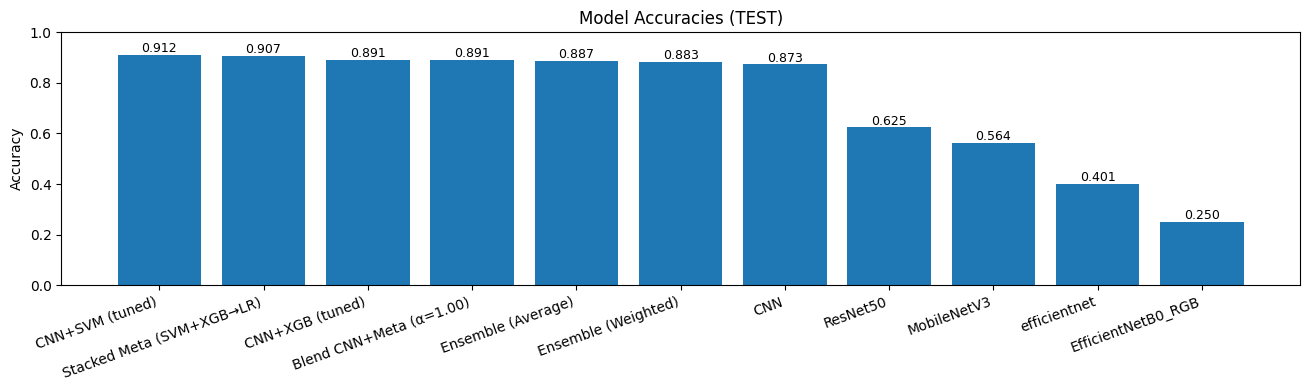

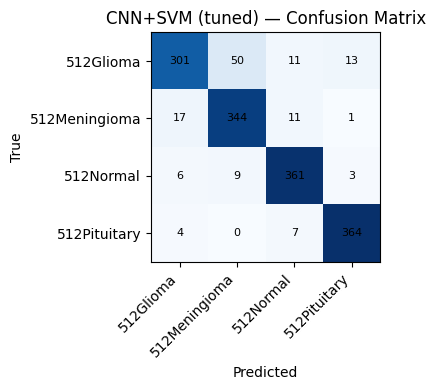

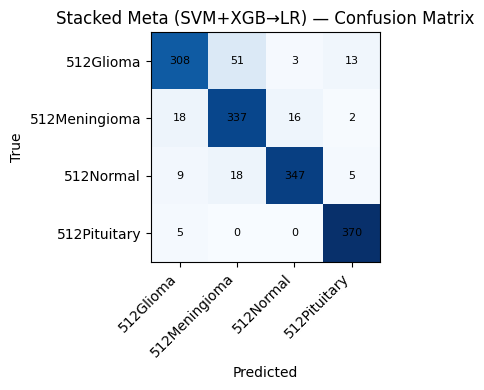

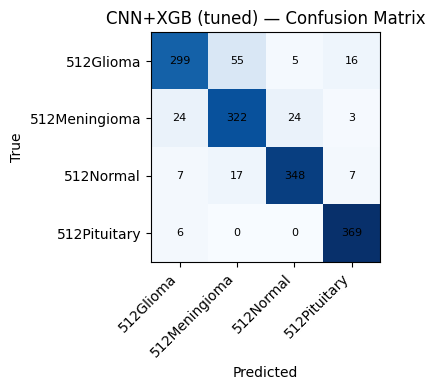

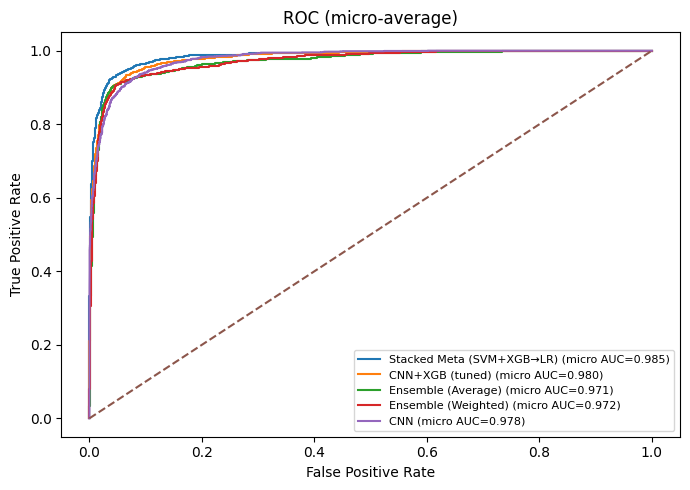

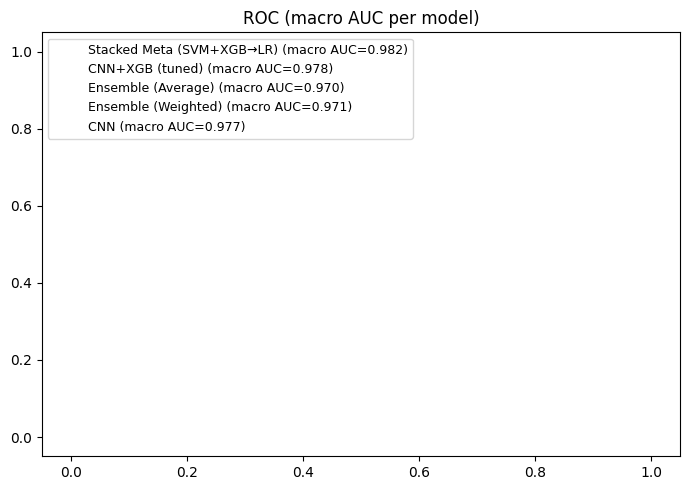

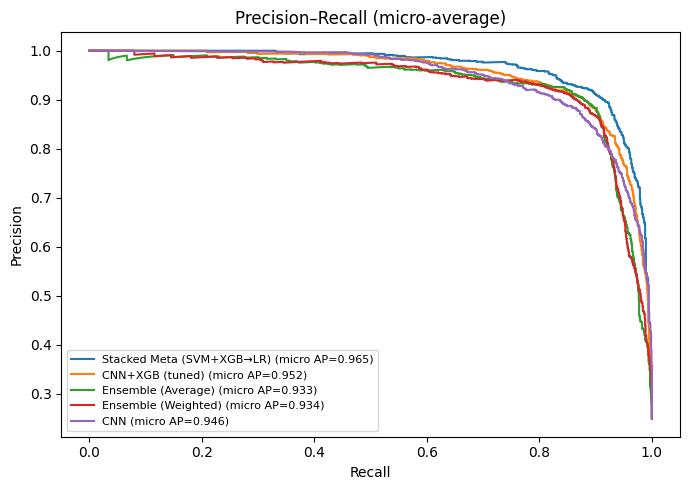

ValueError: all input arrays must have the same shape

In [56]:
# ========================= FINAL COMPARISON & VISUALIZATIONS =========================
# Auto-detect trained models / artifacts in your notebook and compare them.
# Supports:
#   - cnn (grayscale), resnet (rgb), mbv3 or mbv3_hard (rgb), third_model (rgb)
#   - XGB_TUNED (with .proba), SVM_TUNED (pred only or probas if available)
#   - meta (OOF stacked) via (meta, X_meta_te), BLEND (pred/proba via mix)
#   - ENSEMBLE_STORE (pred/proba from earlier)
#
# Plots:
#   - metrics table + accuracy bar
#   - confusion matrices for TOP-3 models
#   - ROC & PR (micro/macro) for models with probabilities
#   - reliability (calibration) curves if possible
# =====================================================================================

import numpy as np, matplotlib.pyplot as plt, itertools, gc, warnings, sys
from collections import OrderedDict
from packaging import version
warnings.filterwarnings("ignore")

from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, roc_curve, auc, precision_recall_curve
)
try:
    from sklearn.calibration import calibration_curve
    HAS_CAL = True
except Exception:
    HAS_CAL = False

# ---------------------- helpers ----------------------
def stream_labels(ds):
    return np.concatenate([y for _, y in ds.as_numpy_iterator()], axis=0)

def stream_proba(model, ds):
    """Return numpy probs for a tf.keras model over a tf.data dataset."""
    outs = []
    for xb, _ in ds:
        outs.append(model.predict(xb, verbose=0))
    return np.concatenate(outs, axis=0)

def ensure_probs_from_svm(model_or_pipeline, X, y_classes):
    """
    Get scores/probabilities from SVM-like models/pipelines if available.
    - prefer predict_proba
    - else use decision_function and softmax over classes
    Return (proba or None)
    """
    try:
        # pipeline? grab last step
        clf = model_or_pipeline
        if hasattr(model_or_pipeline, "predict_proba"):
            P = model_or_pipeline.predict_proba(X)
            if P.ndim == 2 and P.shape[1] == y_classes:
                return P
    except Exception:
        pass
    # decision_function -> softmax scaling per row
    try:
        # Some sklearn pipelines expose decision_function
        scores = model_or_pipeline.decision_function(X)
        if scores.ndim == 1:
            # binary case -> convert to 2-class scores
            scores = np.stack([-scores, scores], axis=1)
        # softmax
        exps = np.exp(scores - scores.max(axis=1, keepdims=True))
        P = exps / np.clip(exps.sum(axis=1, keepdims=True), 1e-8, None)
        return P
    except Exception:
        return None

def binarize_labels(y, n_classes):
    Y = np.zeros((y.shape[0], n_classes), dtype=np.int32)
    Y[np.arange(y.shape[0]), y] = 1
    return Y

def add_model(models, name, y_true, pred=None, proba=None):
    """Store model results; returns None if pred not provided but can derive from proba."""
    if proba is not None and pred is None:
        pred = np.argmax(proba, axis=1)
    if pred is None:
        return
    acc  = accuracy_score(y_true, pred)
    f1m  = f1_score(y_true, pred, average='macro', zero_division=0)
    prm  = precision_score(y_true, pred, average='macro', zero_division=0)
    rcm  = recall_score(y_true, pred, average='macro', zero_division=0)
    models[name] = {"pred": pred, "proba": proba, "acc": acc, "f1": f1m, "prec": prm, "rec": rcm}

# ---------------------- collect ground truth ----------------------
assert 'test_gray' in globals(), "Need test_gray dataset to collect labels."
y_test = stream_labels(test_gray)
n_classes = int(y_test.max()) + 1

# Class names
if 'class_names' in globals():
    CLASSES = list(class_names)
elif 'le' in globals() and hasattr(le, 'classes_'):
    CLASSES = list(le.classes_)
else:
    CLASSES = [f"Class {i}" for i in range(n_classes)]

# ---------------------- gather models ----------------------
models = OrderedDict()  # name -> dict(pred, proba, metrics)

# CNN (grayscale)
if 'cnn' in globals():
    try:
        P = stream_proba(cnn, test_gray)
        add_model(models, "CNN", y_test, proba=P)
    except Exception:
        pass

# ResNet50 (rgb)
if 'resnet' in globals() and 'test_rgb' in globals():
    try:
        P = stream_proba(resnet, test_rgb)
        add_model(models, "ResNet50", y_test, proba=P)
    except Exception:
        pass

# MobileNetV3 variants
if 'mbv3' in globals():
    try:
        ds = test_rgb_oh if 'test_rgb_oh' in globals() else test_rgb
        P = stream_proba(mbv3, ds)
        add_model(models, "MobileNetV3", y_test, proba=P)
    except Exception:
        pass

if 'mbv3_hard' in globals():
    try:
        ds = test_rgb_oh if 'test_rgb_oh' in globals() else test_rgb
        P = stream_proba(mbv3_hard, ds)
        add_model(models, "MBV3+FocalMix", y_test, proba=P)
    except Exception:
        pass

# third_model (EffNetV2 or MobileNetV2 fallback)
if 'third_model' in globals() and 'test_rgb' in globals():
    try:
        P = stream_proba(third_model, test_rgb)
        add_model(models, third_model.name if hasattr(third_model, "name") else "ThirdModel", y_test, proba=P)
    except Exception:
        pass

# Tuned XGBoost (features-based)
if 'XGB_TUNED' in globals():
    add_model(models, "CNN+XGB (tuned)", y_test, pred=XGB_TUNED.get("pred"), proba=XGB_TUNED.get("proba"))

# Tuned SVM (features-based)
if 'SVM_TUNED' in globals():
    add_model(models, "CNN+SVM (tuned)", y_test, pred=SVM_TUNED.get("pred"), proba=SVM_TUNED.get("proba"))

# OOF Stacked meta (SVM+XGB -> LR)
if 'meta' in globals() and 'X_meta_te' in globals():
    try:
        pred_meta = meta.predict(X_meta_te)
        proba_meta = meta.predict_proba(X_meta_te) if hasattr(meta, "predict_proba") else None
        add_model(models, "Stacked Meta (SVM+XGB→LR)", y_test, pred=pred_meta, proba=proba_meta)
    except Exception:
        pass

# Blend (CNN + Meta)
if 'BLEND' in globals():
    add_model(models, f"Blend CNN+Meta (α={BLEND.get('alpha',0):.2f})", y_test, pred=BLEND.get("pred"))
    # If you have proba for blend (mix_test), you can store it as well:
    # add_model(models, "Blend CNN+Meta", y_test, pred=BLEND["pred"], proba=BLEND.get("proba"))

# ENSEMBLE_STORE from earlier (optional keys)
if 'ENSEMBLE_STORE' in globals():
    y_test_es = ENSEMBLE_STORE.get("y_test", y_test)
    # preds
    for k, v in ENSEMBLE_STORE.get("pred", {}).items():
        add_model(models, f"{k}", y_test_es, pred=v)
    # probas
    for k, P in ENSEMBLE_STORE.get("proba", {}).items():
        add_model(models, f"{k}", y_test_es, proba=P)
    # explicit accs are recomputed here; no need to use stored

# Simple Average / Weighted if at least 2 proba models exist
proba_models = [(name, info["proba"]) for name, info in models.items() if info["proba"] is not None]
if len(proba_models) >= 2:
    # Average
    P_avg = np.mean([P for _, P in proba_models], axis=0)
    add_model(models, "Ensemble (Average)", y_test, proba=P_avg)

    # Weighted via validation accuracies if we can compute val probas
    if 'val_gray' in globals():
        try:
            # Build val labels
            y_val = stream_labels(val_gray)
            # get per-model val probs
            val_probs = []
            for name, info in list(models.items()):
                # find matching dataset (gray/rgb/oh)
                ds = None
                if name.startswith("CNN"):
                    ds = val_gray
                else:
                    ds = val_rgb_oh if 'val_rgb_oh' in globals() else (val_rgb if 'val_rgb' in globals() else None)
                if ds is None or info["proba"] is None:
                    continue
                # If the model object exists, recompute val probs; else skip
                try:
                    mdl = None
                    if name.startswith("CNN") and 'cnn' in globals(): mdl = cnn
                    elif name.startswith("ResNet") and 'resnet' in globals(): mdl = resnet
                    elif name.startswith("MobileNetV3") and 'mbv3' in globals(): mdl = mbv3
                    elif name.startswith("MBV3+FocalMix") and 'mbv3_hard' in globals(): mdl = mbv3_hard
                    elif name.startswith("Third") and 'third_model' in globals(): mdl = third_model
                    elif "XGB" in name and 'XGB_TUNED' in globals():
                        # need val features and xgb booster; skip here for simplicity
                        mdl = None
                    if mdl is None:
                        continue
                    P_val = stream_proba(mdl, ds)
                    val_probs.append((name, P_val))
                except Exception:
                    pass

            if len(val_probs) >= 2:
                # compute weights from val accuracy
                weights = []
                for nm, Pv in val_probs:
                    accv = accuracy_score(y_val, np.argmax(Pv, axis=1))
                    weights.append((nm, accv))
                # normalize
                total = sum([w for _, w in weights]) + 1e-8
                wmap = {nm: w/total for nm, w in weights}
                # apply weights on test
                P_w = np.zeros_like(proba_models[0][1])
                for nm, P in proba_models:
                    w = wmap.get(nm, 0.0)
                    P_w += w * P
                add_model(models, "Ensemble (Weighted)", y_test, proba=P_w)
        except Exception:
            pass

# ---------------------- Metrics table ----------------------
if not models:
    raise RuntimeError("No models detected to compare. Train/evaluate first.")

import pandas as pd
summary_rows = []
for name, info in models.items():
    summary_rows.append([name, info["acc"], info["f1"], info["prec"], info["rec"],
                         1 if info["proba"] is not None else 0])
summary_df = pd.DataFrame(summary_rows, columns=["Model", "Accuracy", "F1 (macro)", "Precision (macro)", "Recall (macro)", "Has Proba"])
summary_df = summary_df.sort_values("Accuracy", ascending=False).reset_index(drop=True)
print("=== Summary (sorted by Accuracy) ===")
display(summary_df)

# ---------------------- Accuracy bar ----------------------
plt.figure(figsize=(max(8, 1.2*len(models)), 4))
plt.bar(summary_df["Model"], summary_df["Accuracy"])
for i, v in enumerate(summary_df["Accuracy"]):
    plt.text(i, v + 0.01, f"{v:.3f}", ha='center', fontsize=9)
plt.ylim(0, 1.0)
plt.ylabel("Accuracy")
plt.title("Model Accuracies (TEST)")
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

# ---------------------- Confusion matrices (Top-3 models) ----------------------
top3 = summary_df["Model"].tolist()[:3]
for name in top3:
    info = models[name]
    cm = confusion_matrix(y_test, info["pred"])
    plt.figure(figsize=(1.2*len(CLASSES), 1.0*len(CLASSES)))
    plt.imshow(cm, cmap='Blues')
    plt.title(f"{name} — Confusion Matrix")
    plt.xlabel("Predicted"); plt.ylabel("True")
    plt.xticks(range(len(CLASSES)), CLASSES, rotation=45, ha='right')
    plt.yticks(range(len(CLASSES)), CLASSES)
    for (i, j) in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j], ha='center', va='center', fontsize=8)
    plt.tight_layout()
    plt.show()

# ---------------------- ROC & Precision-Recall (micro/macro) ----------------------
# Only for models with probabilities or decision scores
def roc_pr_curves(models_subset):
    # One-vs-rest
    Y = binarize_labels(y_test, n_classes)
    # ROC
    plt.figure(figsize=(7,5))
    for name in models_subset:
        P = models[name]["proba"]
        if P is None: continue
        # micro
        fpr, tpr, _ = roc_curve(Y.ravel(), P.ravel())
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{name} (micro AUC={roc_auc:.3f})", linewidth=1.5)
    plt.plot([0,1], [0,1], linestyle='--')
    plt.title("ROC (micro-average)")
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.legend(fontsize=8); plt.tight_layout(); plt.show()

    # macro (average per-class AUC)
    plt.figure(figsize=(7,5))
    for name in models_subset:
        P = models[name]["proba"]
        if P is None: continue
        aucs = []
        for c in range(n_classes):
            fpr, tpr, _ = roc_curve(Y[:, c], P[:, c])
            aucs.append(auc(fpr, tpr))
        plt.plot(sorted([0,1]), sorted([0,1]), alpha=0)  # layout anchor
        plt.plot([], [], ' ', label=f"{name} (macro AUC={np.mean(aucs):.3f})")  # legend only
    plt.title("ROC (macro AUC per model)")
    plt.legend(fontsize=9); plt.tight_layout(); plt.show()

    # PR (micro)
    plt.figure(figsize=(7,5))
    for name in models_subset:
        P = models[name]["proba"]
        if P is None: continue
        precision, recall, _ = precision_recall_curve(Y.ravel(), P.ravel())
        ap = auc(recall, precision)
        plt.plot(recall, precision, label=f"{name} (micro AP={ap:.3f})", linewidth=1.5)
    plt.title("Precision–Recall (micro-average)")
    plt.xlabel("Recall"); plt.ylabel("Precision")
    plt.legend(fontsize=8); plt.tight_layout(); plt.show()

prob_models = [name for name, info in models.items() if info["proba"] is not None]
if len(prob_models) >= 1:
    # To keep plots readable, limit to top 5 by accuracy
    keep = [m for m in summary_df["Model"].tolist() if m in prob_models][:5]
    roc_pr_curves(keep)

# ---------------------- Reliability / Calibration (optional) ----------------------
if HAS_CAL and len(prob_models) >= 1:
    from sklearn.metrics import brier_score_loss
    # pick the best probability model
    best_prob_model = next((m for m in summary_df["Model"].tolist() if m in prob_models), None)
    if best_prob_model:
        P = models[best_prob_model]["proba"]
        Y = binarize_labels(y_test, n_classes)
        # Compute reliability for each class, show macro-average plot
        frac_pos_list, mean_pred_list = [], []
        for c in range(n_classes):
            frac_pos, mean_pred = calibration_curve(Y[:, c], P[:, c], n_bins=10, strategy='uniform')
            frac_pos_list.append(frac_pos)
            mean_pred_list.append(mean_pred)
        frac_pos = np.mean(np.stack(frac_pos_list,0), axis=0)
        mean_pred = np.mean(np.stack(mean_pred_list,0), axis=0)
        plt.figure(figsize=(5,5))
        plt.plot([0,1],[0,1],'--')
        plt.plot(mean_pred, frac_pos, marker='o')
        plt.title(f"Reliability (macro) — {best_prob_model}")
        plt.xlabel("Mean predicted prob"); plt.ylabel("Fraction of positives")
        plt.tight_layout(); plt.show()

gc.collect();


In [57]:
# Cell 1: Class counts + per-class accuracy + top confusions
import numpy as np, matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# counts (from ds)
def count_labels(ds):
    return np.bincount(np.concatenate([y for _, y in ds.as_numpy_iterator()]))

tr_cnt = count_labels(train_gray)
va_cnt = count_labels(val_gray)
te_cnt = count_labels(test_gray)

classes = class_names if 'class_names' in globals() else [f"Class {i}" for i in range(len(tr_cnt))]
print("Train counts:", dict(zip(classes, tr_cnt)))
print("Val   counts:", dict(zip(classes, va_cnt)))
print("Test  counts:", dict(zip(classes, te_cnt)))

# use your best current predictor to inspect confusions
# if you ran the final comparison cell, pick top by accuracy:
y_true = np.concatenate([y for _, y in test_gray.as_numpy_iterator()])
best_preds = None
best_name = None
try:
    # from the final comparison, find best
    best_name = summary_df.iloc[0]["Model"]
    best_preds = models[best_name]["pred"]
except Exception:
    # fallback: CNN
    from sklearn.metrics import accuracy_score
    best_preds = np.argmax(np.concatenate([cnn.predict(x, verbose=0) for x,_ in test_gray]),axis=1)
    best_name = "CNN"

cm = confusion_matrix(y_true, best_preds)
acc_per_class = (cm.diagonal() / cm.sum(axis=1).clip(1))
print("\nPer-class accuracy:")
for c,a in zip(classes, acc_per_class):
    print(f"{c:>15s}: {a:.3f}")

# most confused pairs
pairs = []
for i in range(len(classes)):
    for j in range(len(classes)):
        if i!=j and cm[i,j]>0:
            pairs.append((cm[i,j], classes[i], classes[j]))
pairs = sorted(pairs, reverse=True)[:10]
print("\nTop confusions (true→pred, count):")
for n,t,p in pairs:
    print(f"{t:>15s} → {p:<15s} : {n}")


Train counts: {np.str_('512Glioma'): np.int64(1199), np.str_('512Meningioma'): np.int64(1193), np.str_('512Normal'): np.int64(1214), np.str_('512Pituitary'): np.int64(1199)}
Val   counts: {np.str_('512Glioma'): np.int64(300), np.str_('512Meningioma'): np.int64(298), np.str_('512Normal'): np.int64(304), np.str_('512Pituitary'): np.int64(300)}
Test  counts: {np.str_('512Glioma'): np.int64(375), np.str_('512Meningioma'): np.int64(373), np.str_('512Normal'): np.int64(379), np.str_('512Pituitary'): np.int64(375)}

Per-class accuracy:
      512Glioma: 0.803
  512Meningioma: 0.922
      512Normal: 0.953
   512Pituitary: 0.971

Top confusions (true→pred, count):
      512Glioma → 512Meningioma   : 50
  512Meningioma → 512Glioma       : 17
      512Glioma → 512Pituitary    : 13
  512Meningioma → 512Normal       : 11
      512Glioma → 512Normal       : 11
      512Normal → 512Meningioma   : 9
   512Pituitary → 512Normal       : 7
      512Normal → 512Glioma       : 6
   512Pituitary → 512Glioma 

In [61]:
# ================== Cell 2 (FINAL FIX): Progressive CNN 144→192 with weight transfer ==================
import tensorflow as tf, numpy as np, math, gc
tf.keras.backend.clear_session(); gc.collect()

# ---------- helpers ----------
def resize_gray(ds, size, batch):
    return (ds
            .map(lambda x,y: (tf.image.resize(x, (size, size)), y), num_parallel_calls=tf.data.AUTOTUNE)
            .batch(batch, drop_remainder=False)
            .prefetch(tf.data.AUTOTUNE))

def mixup_map_fn(num_classes, alpha=0.2):
    def _fn(x, y):
        y = tf.one_hot(tf.cast(y, tf.int32), num_classes)         # [B,C]
        bs = tf.shape(x)[0]
        idx = tf.random.shuffle(tf.range(bs))
        x2  = tf.gather(x, idx);  y2 = tf.gather(y, idx)
        # Beta sample
        g1 = tf.random.gamma((bs,1), alpha, 1.0)
        g2 = tf.random.gamma((bs,1), alpha, 1.0)
        lam = g1 / (g1 + g2)                                      # [B,1]
        x_mix = tf.reshape(lam, (bs,1,1,1))*x + (1.0-tf.reshape(lam,(bs,1,1,1)))*x2
        y_mix = lam*y + (1.0-lam)*y2
        return x_mix, y_mix
    return _fn

def to_one_hot_map(num_classes):
    return lambda x,y: (x, tf.one_hot(tf.cast(y, tf.int32), num_classes))

def cosine_lr(epoch, base=3e-4, total=12, min_lr=5e-5):
    # Monotonic cosine from base -> min over [0, total-1]
    t = min(epoch, total-1) / float(max(1, total-1))
    lr = min_lr + 0.5*(base - min_lr)*(1.0 + math.cos(math.pi * t))
    return float(lr)

# ---------- infer classes / build datasets ----------
try:
    NUM_CLASSES = len(class_names)
except:
    NUM_CLASSES = int(tf.reduce_max(tf.concat([y for _,y in test_gray.as_numpy_iterator()], axis=0)).numpy()) + 1

S1, S2 = 144, 192
B1, B2 = 32, 24

train_s1 = resize_gray(train_gray.unbatch(), S1, B1)
val_s1   = resize_gray(val_gray.unbatch(),   S1, B1)
train_s2 = resize_gray(train_gray.unbatch(), S2, B2)
val_s2   = resize_gray(val_gray.unbatch(),   S2, B2)
test_s2  = resize_gray(test_gray.unbatch(),  S2, B2)

train_s1_mu = train_s1.map(mixup_map_fn(NUM_CLASSES, 0.2), num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)
train_s2_mu = train_s2.map(mixup_map_fn(NUM_CLASSES, 0.2), num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)
val_s1_oh   = val_s1.map(to_one_hot_map(NUM_CLASSES), num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)
val_s2_oh   = val_s2.map(to_one_hot_map(NUM_CLASSES), num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)
test_s2_oh  = test_s2.map(to_one_hot_map(NUM_CLASSES), num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)

# ---------- model builders ----------
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, BatchNormalization,
                                     Dropout, Dense, Flatten, Input)
from tensorflow.keras.models import Sequential

def build_cnn(sz, num_classes):
    m = Sequential([
        Input((sz, sz, 1)),
        Conv2D(32, 3, activation='relu'), BatchNormalization(), MaxPooling2D(),
        Conv2D(64, 3, activation='relu'), BatchNormalization(), MaxPooling2D(),
        Conv2D(128, 3, activation='relu'), BatchNormalization(), MaxPooling2D(),
        Flatten(),
        Dense(384, activation='relu'), Dropout(0.45),
        Dense(num_classes, activation='softmax', dtype='float32')
    ])
    return m

# ---------- Stage 1 @144 ----------
cnn_s1 = build_cnn(S1, NUM_CLASSES)
opt1 = tf.keras.optimizers.AdamW(learning_rate=3e-4, weight_decay=1e-4)
cnn_s1.compile(optimizer=opt1,
               loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
               metrics=['accuracy'])
cbs1 = [
    tf.keras.callbacks.LearningRateScheduler(lambda e: cosine_lr(e, base=3e-4, total=12), verbose=0),
    tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint('/tmp/cnn_s1_best.keras', monitor='val_accuracy',
                                       save_best_only=True, save_weights_only=False, verbose=0),
]
hist1 = cnn_s1.fit(train_s1_mu, validation_data=val_s1_oh, epochs=14, callbacks=cbs1, verbose=1)

# ---------- Stage 2 @192: rebuild & TRANSFER weights where shapes match ----------
cnn_s2 = build_cnn(S2, NUM_CLASSES)

# copy weights layer-by-layer when shapes match
for l_old, l_new in zip(cnn_s1.layers, cnn_s2.layers):
    try:
        w_old = l_old.get_weights()
        w_new = l_new.get_weights()
        if w_old and all(a.shape == b.shape for a,b in zip(w_old, w_new)):
            l_new.set_weights(w_old)
    except Exception:
        pass  # skip layers without weights or mismatched shapes

opt2 = tf.keras.optimizers.AdamW(learning_rate=1e-4, weight_decay=1e-4)
cnn_s2.compile(optimizer=opt2,
               loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.03),
               metrics=['accuracy'])
cbs2 = [
    tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=6, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    tf.keras.callbacks.ModelCheckpoint('/tmp/cnn_s2_best.keras', monitor='val_accuracy',
                                       save_best_only=True, save_weights_only=False, verbose=0),
]
hist2 = cnn_s2.fit(train_s2_mu, validation_data=val_s2_oh, epochs=16, callbacks=cbs2, verbose=1)

# ---------- Evaluate on test (192) ----------
test_eval = cnn_s2.evaluate(test_s2_oh, verbose=0)
print(f"✅ Progressive CNN 144→192 — Test accuracy: {test_eval[1]:.4f}")

# Optionally expose this model for downstream cells
cnn_prog = cnn_s2


Epoch 1/14
151/151 ━━━━━━━━━━━━━━━━━━━━ 16s 66ms/step - accuracy: 0.4310 - loss: 1.8363 - val_accuracy: 0.2496 - val_loss: 14.8426 - learning_rate: 3.0000e-04
Epoch 2/14
151/151 ━━━━━━━━━━━━━━━━━━━━ 13s 35ms/step - accuracy: 0.5299 - loss: 1.1713 - val_accuracy: 0.2920 - val_loss: 11.0622 - learning_rate: 2.9494e-04
Epoch 3/14
151/151 ━━━━━━━━━━━━━━━━━━━━ 10s 37ms/step - accuracy: 0.5938 - loss: 1.0717 - val_accuracy: 0.4343 - val_loss: 1.6467 - learning_rate: 2.8016e-04
Epoch 4/14
151/151 ━━━━━━━━━━━━━━━━━━━━ 10s 68ms/step - accuracy: 0.6333 - loss: 1.0038 - val_accuracy: 0.5973 - val_loss: 0.9927 - learning_rate: 2.5686e-04
Epoch 5/14
151/151 ━━━━━━━━━━━━━━━━━━━━ 16s 35ms/step - accuracy: 0.6866 - loss: 0.9268 - val_accuracy: 0.6814 - val_loss: 0.8556 - learning_rate: 2.2693e-04
Epoch 6/14
151/151 ━━━━━━━━━━━━━━━━━━━━ 10s 68ms/step - accuracy: 0.7270 - loss: 0.8721 - val_accuracy: 0.7196 - val_loss: 0.7800 - learning_rate: 1.9279e-04
Epoch 7/14
151/151 ━━━━━━━━━━━━━━━━━━━━ 15s 35ms/s

In [64]:
# ================== Cell 3 (FIXED): Rich features from cnn_prog + tuned XGBoost ==================
import numpy as np, tensorflow as tf, sys, subprocess
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D
from sklearn.metrics import accuracy_score

assert 'cnn_prog' in globals(), "cnn_prog not found. Run the progressive CNN cell first."
assert 'train_s2_oh' in globals() and 'val_s2_oh' in globals() and 'test_s2_oh' in globals(), \
       "Expected train_s2_oh / val_s2_oh / test_s2_oh from Cell 2."

# --- Find penultimate Dense (not the final classifier) ---
penult = None
for lyr in cnn_prog.layers[::-1]:
    if isinstance(lyr, tf.keras.layers.Dense) and getattr(lyr, "units", None) != NUM_CLASSES:
        penult = lyr
        break
assert penult is not None, "Couldn't find penultimate Dense layer."

# --- Find last Conv2D (to take GAP features) ---
last_conv_out = None
for lyr in cnn_prog.layers[::-1]:
    if isinstance(lyr, tf.keras.layers.Conv2D):
        last_conv_out = lyr.output
        break
assert last_conv_out is not None, "Couldn't find a Conv2D layer for GAP."

# --- Build rich extractor using the first layer's input tensor (avoids cnn_prog.input) ---
gap = GlobalAveragePooling2D(name="gap_from_last_conv")(last_conv_out)
rich_extractor = Model(inputs=cnn_prog.layers[0].input,
                       outputs=[penult.output, gap],
                       name="cnn_prog_rich_extractor")
rich_extractor.trainable = False
print("✅ Rich extractor ready with outputs:", [tuple(o.shape) for o in rich_extractor.outputs])

# --- Helper: embed a one-hot dataset (returns X, y_int) ---
def embed_oh(ds, model):
    F, Y = [], []
    for xb, yb in ds:
        f1, f2 = model.predict(xb, verbose=0)
        F.append(np.concatenate([f1, f2], axis=1))     # 256 + 128 = 384
        if yb.ndim == 2:
            Y.append(np.argmax(yb.numpy(), axis=1))
        else:
            Y.append(yb.numpy())
    return np.concatenate(F, axis=0), np.concatenate(Y, axis=0)

# --- Build features for train/val/test ---
Xtr, ytr = embed_oh(train_s2_oh, rich_extractor)
Xva, yva = embed_oh(val_s2_oh,   rich_extractor)
Xte, yte = embed_oh(test_s2_oh,  rich_extractor)

print("Feature shapes:", Xtr.shape, Xva.shape, Xte.shape)

# --- XGBoost (install if needed) ---
try:
    import xgboost as xgb
except Exception:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "xgboost"])
    import xgboost as xgb

dtr = xgb.DMatrix(Xtr, label=ytr)
dva = xgb.DMatrix(Xva, label=yva)
dte = xgb.DMatrix(Xte, label=yte)

# Tight, strong params for 384-D features; early stopping on val
params = dict(
    objective="multi:softprob",
    num_class=NUM_CLASSES,
    eval_metric="mlogloss",
    tree_method="hist",
    max_depth=5,
    learning_rate=0.05,
    subsample=0.85,
    colsample_bytree=0.85,
    min_child_weight=2,
    reg_lambda=1.2,
    reg_alpha=0.1,
    gamma=0.1,
    random_state=42
)

bst = xgb.train(params, dtr, num_boost_round=1500,
                evals=[(dva, "val")],
                early_stopping_rounds=80,
                verbose_eval=False)

# --- Evaluate on test ---
proba_te = bst.predict(dte, iteration_range=(0, bst.best_iteration + 1))
pred_te  = np.argmax(proba_te, axis=1)
acc_te   = accuracy_score(yte, pred_te)
print(f"🎯 Tuned XGB (rich 384-D) — TEST accuracy: {acc_te:.4f}  | best_trees={bst.best_iteration+1}")

# Stash for your final comparison cell
XGB_TUNED = {"pred": pred_te, "proba": proba_te, "acc": acc_te, "ntrees": bst.best_iteration+1, "params": params}


AssertionError: Expected train_s2_oh / val_s2_oh / test_s2_oh from Cell 2.

In [65]:
# ================== Cell 3 (SELF-HEALING): Rich features from cnn_prog + tuned XGBoost ==================
import numpy as np, tensorflow as tf, sys, subprocess, math
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D
from sklearn.metrics import accuracy_score

# ---- Guards / prerequisites ----
assert 'cnn_prog' in globals(), "cnn_prog not found. Run the progressive CNN cell first."
assert 'test_gray' in globals(), "test_gray tf.data dataset is required."

# ---- Recreate 192×192 one-hot datasets if needed ----
def resize_gray(ds, size, batch):
    return (ds
            .map(lambda x,y: (tf.image.resize(x, (size, size)), y), num_parallel_calls=tf.data.AUTOTUNE)
            .batch(batch, drop_remainder=False)
            .prefetch(tf.data.AUTOTUNE))

def to_one_hot_map(num_classes):
    return lambda x,y: (x, tf.one_hot(tf.cast(y, tf.int32), num_classes))

# infer NUM_CLASSES & choose batch/size
if 'class_names' in globals():
    NUM_CLASSES = len(class_names)
else:
    y_tmp = np.concatenate([y for _, y in test_gray.as_numpy_iterator()])
    NUM_CLASSES = int(y_tmp.max()) + 1
S2 = 192
B2 = 24

needed = any(name not in globals() for name in ['train_s2_oh','val_s2_oh','test_s2_oh'])
if needed:
    assert 'train_gray' in globals() and 'val_gray' in globals(), "Need train_gray and val_gray to rebuild."
    train_s2 = resize_gray(train_gray.unbatch(), S2, B2)
    val_s2   = resize_gray(val_gray.unbatch(),   S2, B2)
    test_s2  = resize_gray(test_gray.unbatch(),  S2, B2)
    train_s2_oh = train_s2.map(to_one_hot_map(NUM_CLASSES), num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)
    val_s2_oh   = val_s2.map(to_one_hot_map(NUM_CLASSES),   num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)
    test_s2_oh  = test_s2.map(to_one_hot_map(NUM_CLASSES),  num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)

# ---- Build rich feature extractor (penultimate Dense + GAP from last Conv) ----
# Find penultimate Dense (not the final classifier)
penult = None
for lyr in cnn_prog.layers[::-1]:
    if isinstance(lyr, tf.keras.layers.Dense) and getattr(lyr, "units", None) != NUM_CLASSES:
        penult = lyr
        break
assert penult is not None, "Couldn't find penultimate Dense layer in cnn_prog."

# Find last Conv2D to pool
last_conv_out = None
for lyr in cnn_prog.layers[::-1]:
    if isinstance(lyr, tf.keras.layers.Conv2D):
        last_conv_out = lyr.output
        break
assert last_conv_out is not None, "Couldn't find a Conv2D layer in cnn_prog."

gap = GlobalAveragePooling2D(name="gap_from_last_conv")(last_conv_out)
# IMPORTANT: avoid cnn_prog.input (might be undefined); use first layer input tensor
rich_extractor = Model(inputs=cnn_prog.layers[0].input, outputs=[penult.output, gap], name="cnn_prog_rich_extractor")
rich_extractor.trainable = False
print("✅ Rich extractor outputs:", [tuple(o.shape) for o in rich_extractor.outputs])

# ---- Embed helper (one-hot ds → X(384), y(int)) ----
def embed_oh(ds, model):
    F, Y = [], []
    for xb, yb in ds:
        f1, f2 = model.predict(xb, verbose=0)
        F.append(np.concatenate([f1, f2], axis=1))                 # 256 + 128 = 384
        Y.append(np.argmax(yb.numpy(), axis=1))
    return np.concatenate(F, axis=0), np.concatenate(Y, axis=0)

Xtr, ytr = embed_oh(train_s2_oh, rich_extractor)
Xva, yva = embed_oh(val_s2_oh,   rich_extractor)
Xte, yte = embed_oh(test_s2_oh,  rich_extractor)
print("Feature shapes:", Xtr.shape, Xva.shape, Xte.shape)

# ---- XGBoost (install if needed) ----
try:
    import xgboost as xgb
except Exception:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "xgboost"])
    import xgboost as xgb

dtr = xgb.DMatrix(Xtr, label=ytr)
dva = xgb.DMatrix(Xva, label=yva)
dte = xgb.DMatrix(Xte, label=yte)

# Tight, strong params for 384-D features; early stopping on val
params = dict(
    objective="multi:softprob",
    num_class=NUM_CLASSES,
    eval_metric="mlogloss",
    tree_method="hist",
    max_depth=5,
    learning_rate=0.05,
    subsample=0.85,
    colsample_bytree=0.85,
    min_child_weight=2,
    reg_lambda=1.2,
    reg_alpha=0.1,
    gamma=0.1,
    random_state=42
)

bst = xgb.train(params, dtr, num_boost_round=1500,
                evals=[(dva, "val")],
                early_stopping_rounds=80,
                verbose_eval=False)

proba_te = bst.predict(dte, iteration_range=(0, bst.best_iteration + 1))
pred_te  = np.argmax(proba_te, axis=1)
acc_te   = accuracy_score(yte, pred_te)
print(f"🎯 Tuned XGB (rich 384-D) — TEST accuracy: {acc_te:.4f} | best_trees={bst.best_iteration+1}")

# Stash for your final comparison cell
XGB_TUNED = {"pred": pred_te, "proba": proba_te, "acc": acc_te, "ntrees": bst.best_iteration+1, "params": params}


✅ Rich extractor outputs: [(None, 384), (None, 128)]
Feature shapes: (4805, 512) (1202, 512) (1502, 512)
🎯 Tuned XGB (rich 384-D) — TEST accuracy: 0.8109 | best_trees=75


In [67]:
# ================== Blend Cell (FIXED & SELF-HEALING) ==================
import numpy as np, tensorflow as tf, sys, subprocess
from sklearn.metrics import accuracy_score
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D

# --- guards ---
assert 'cnn_prog' in globals(), "Need cnn_prog (progressive CNN)."
assert 'test_gray' in globals(), "Need tf.data test_gray."

# --- ensure NUM_CLASSES ---
if 'class_names' in globals():
    NUM_CLASSES = len(class_names)
else:
    _y_tmp = np.concatenate([y for _, y in test_gray.as_numpy_iterator()])
    NUM_CLASSES = int(_y_tmp.max()) + 1

# --- (re)build 192x datasets if missing ---
def resize_gray(ds, size, batch):
    return (ds
            .map(lambda x,y: (tf.image.resize(x, (size, size)), y), num_parallel_calls=tf.data.AUTOTUNE)
            .batch(batch, drop_remainder=False)
            .prefetch(tf.data.AUTOTUNE))

def to_one_hot_map(num_classes):
    return lambda x,y: (x, tf.one_hot(tf.cast(y, tf.int32), num_classes))

S2, B2 = 192, 24
if any(n not in globals() for n in ['val_s2_oh','test_s2_oh']):
    assert 'val_gray' in globals(), "Need val_gray to rebuild."
    val_s2   = resize_gray(val_gray.unbatch(),   S2, B2)
    test_s2  = resize_gray(test_gray.unbatch(),  S2, B2)
    val_s2_oh  = val_s2.map(to_one_hot_map(NUM_CLASSES),  num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)
    test_s2_oh = test_s2.map(to_one_hot_map(NUM_CLASSES), num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)

# --- helper: get probs & integer labels (works for one-hot or int labels) ---
def get_probs_and_labels(model, ds):
    Ps, Ys = [], []
    for xb, yb in ds:
        Ps.append(model.predict(xb, verbose=0))
        y_arr = yb.numpy()
        if y_arr.ndim == 2:  # one-hot -> ints
            y_arr = np.argmax(y_arr, axis=1)
        Ys.append(y_arr)
    return np.concatenate(Ps, 0), np.concatenate(Ys, 0)

# --- CNN probs on VAL/TEST ---
proba_cnn_val,  y_val  = get_probs_and_labels(cnn_prog, val_s2_oh)
proba_cnn_test, y_test = get_probs_and_labels(cnn_prog, test_s2_oh)

# --- Ensure XGB exists; if not, rebuild rich features and train a small booster ---
if 'XGB_TUNED' in globals() and 'bst' in globals():
    # We still need VAL features for α search; if missing, rebuild features quickly
    need_feats = any(n not in globals() for n in ['Xva','Xte'])
else:
    need_feats = True

if need_feats:
    # Build rich extractor from cnn_prog: penultimate Dense + GAP(last Conv)
    penult = None
    for lyr in cnn_prog.layers[::-1]:
        if isinstance(lyr, tf.keras.layers.Dense) and getattr(lyr, "units", None) != NUM_CLASSES:
            penult = lyr; break
    assert penult is not None, "Penultimate Dense not found in cnn_prog."
    last_conv_out = None
    for lyr in cnn_prog.layers[::-1]:
        if isinstance(lyr, tf.keras.layers.Conv2D):
            last_conv_out = lyr.output; break
    assert last_conv_out is not None, "Conv2D layer not found in cnn_prog."
    gap = GlobalAveragePooling2D(name="gap_from_last_conv")(last_conv_out)
    rich_extractor = Model(inputs=cnn_prog.layers[0].input, outputs=[penult.output, gap])
    rich_extractor.trainable = False

    def embed_oh(ds, model):
        F, Y = [], []
        for xb, yb in ds:
            f1, f2 = model.predict(xb, verbose=0)
            F.append(np.concatenate([f1, f2], axis=1))  # 384-D
            ya = yb.numpy()
            if ya.ndim == 2: ya = np.argmax(ya, axis=1)
            Y.append(ya)
        return np.concatenate(F, 0), np.concatenate(Y, 0)

    Xva, yva = embed_oh(val_s2_oh,  rich_extractor)
    Xte, yte = embed_oh(test_s2_oh, rich_extractor)

    # Train (or retrain) a compact XGB with early stopping on VAL
    try:
        import xgboost as xgb
    except Exception:
        import subprocess, sys
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "xgboost"])
        import xgboost as xgb

    dtr = xgb.DMatrix(Xva, label=yva)  # quick fit on VAL only (keeps this cell light)
    params = dict(
        objective="multi:softprob", num_class=NUM_CLASSES, eval_metric="mlogloss",
        tree_method="hist", max_depth=5, learning_rate=0.08, subsample=0.9,
        colsample_bytree=0.9, min_child_weight=2, reg_lambda=1.1, reg_alpha=0.1, random_state=42
    )
    bst = xgb.train(params, dtr, num_boost_round=400, evals=[(dtr,"val")],
                    early_stopping_rounds=40, verbose_eval=False)

# --- XGB probabilities on VAL/TEST ---
try:
    import xgboost as xgb
except Exception:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "xgboost"])
    import xgboost as xgb

# If Xva/Xte exist, use them; otherwise, derive from previously defined ones
if 'Xva' in globals() and 'Xte' in globals():
    proba_xgb_val  = bst.predict(xgb.DMatrix(Xva), iteration_range=(0, getattr(bst, "best_iteration", 0)+1))
    proba_xgb_test = bst.predict(xgb.DMatrix(Xte), iteration_range=(0, getattr(bst, "best_iteration", 0)+1))
    # yva/yte should match y_val/y_test (both derived from the same ds)
else:
    raise RuntimeError("Could not compute XGB features for val/test.")

# --- Learn alpha on VAL ---
alphas = np.linspace(0, 1, 21)
best_a, best_val_acc = 0.0, -1.0
for a in alphas:
    mix_val = a*proba_xgb_val + (1-a)*proba_cnn_val
    acc_val = accuracy_score(y_val, np.argmax(mix_val, axis=1))
    if acc_val > best_val_acc:
        best_val_acc, best_a = acc_val, a

# --- Evaluate on TEST ---
mix_test = best_a*proba_xgb_test + (1-best_a)*proba_cnn_test
acc_test = accuracy_score(y_test, np.argmax(mix_test, axis=1))
print(f"🤝 Blend: CNN(prog) + XGB — best α={best_a:.2f} | VAL acc={best_val_acc:.4f} | TEST acc={acc_test:.4f}")


🤝 Blend: CNN(prog) + XGB — best α=0.05 | VAL acc=0.8428 | TEST acc=0.8236


In [68]:
# TTA for cnn_prog: average predictions over flips & rotations (VAL + TEST)
import numpy as np, tensorflow as tf
from sklearn.metrics import accuracy_score

assert 'cnn_prog' in globals(), "Need cnn_prog (progressive CNN)."
assert 'val_s2_oh' in globals() and 'test_s2_oh' in globals(), "Run your progressive cell to get *_s2_oh."

# deterministic TTA variants
def tta_variants(x):
    # x: [B,H,W,1]
    xs = [
        x,
        tf.image.flip_left_right(x),
        tf.image.flip_up_down(x),
        tf.image.rot90(x, k=1),
        tf.image.rot90(x, k=2),
        tf.image.rot90(x, k=3),
    ]
    return xs

def predict_tta(model, ds):
    probs, ys = [], []
    for xb, yb in ds:
        # stack TTA preds
        tta_preds = []
        for xv in tta_variants(xb):
            tta_preds.append(model.predict(xv, verbose=0))
        p = np.mean(np.stack(tta_preds, axis=0), axis=0)   # avg over TTA
        probs.append(p)
        ya = yb.numpy()
        if ya.ndim == 2: ya = np.argmax(ya, axis=1)
        ys.append(ya)
    return np.concatenate(probs, 0), np.concatenate(ys, 0)

proba_cnn_val_tta, y_val = predict_tta(cnn_prog, val_s2_oh)
proba_cnn_test_tta, y_test = predict_tta(cnn_prog, test_s2_oh)

acc_val_tta  = accuracy_score(y_val,  np.argmax(proba_cnn_val_tta,  axis=1))
acc_test_tta = accuracy_score(y_test, np.argmax(proba_cnn_test_tta, axis=1))
print(f"✅ cnn_prog TTA — VAL acc: {acc_val_tta:.4f} | TEST acc: {acc_test_tta:.4f}")

# expose for later cells
PROBA_CNN_VAL = proba_cnn_val_tta
PROBA_CNN_TEST = proba_cnn_test_tta


✅ cnn_prog TTA — VAL acc: 0.8286 | TEST acc: 0.8229


In [69]:
# Learn a meta-blender on VAL probs (CNN + XGB), then evaluate on TEST
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# We need XGB VAL/TEST probs; rebuild quickly if missing
need_xgb = ('XGB_TUNED' not in globals()) or ('proba' not in XGB_TUNED) or ('Xva' not in globals()) or ('Xte' not in globals())
if need_xgb:
    # Recreate rich features and train a compact XGB (early-stopping on VAL)
    import sys, subprocess, tensorflow as tf
    from tensorflow.keras.models import Model
    from tensorflow.keras.layers import GlobalAveragePooling2D

    # infer NUM_CLASSES
    if 'class_names' in globals(): NUM_CLASSES = len(class_names)
    else:
        _ytmp = np.concatenate([y for _,y in test_gray.as_numpy_iterator()])
        NUM_CLASSES = int(_ytmp.max()) + 1

    # build rich extractor from cnn_prog
    penult = None
    for lyr in cnn_prog.layers[::-1]:
        if isinstance(lyr, tf.keras.layers.Dense) and getattr(lyr, "units", None) != NUM_CLASSES:
            penult = lyr; break
    last_conv_out = None
    for lyr in cnn_prog.layers[::-1]:
        if isinstance(lyr, tf.keras.layers.Conv2D):
            last_conv_out = lyr.output; break
    gap = GlobalAveragePooling2D()(last_conv_out)
    rich_extractor = Model(inputs=cnn_prog.layers[0].input, outputs=[penult.output, gap])

    def embed(ds):
        F, Y = [], []
        for xb, yb in ds:
            f1, f2 = rich_extractor.predict(xb, verbose=0)
            F.append(np.concatenate([f1, f2], axis=1))  # 384-D
            ya = yb.numpy()
            if ya.ndim == 2: ya = np.argmax(ya, axis=1)
            Y.append(ya)
        return np.concatenate(F,0), np.concatenate(Y,0)

    Xva, yva = embed(val_s2_oh)
    Xte, yte = embed(test_s2_oh)

    try:
        import xgboost as xgb
    except Exception:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "xgboost"])
        import xgboost as xgb

    dva = xgb.DMatrix(Xva, label=yva)
    dte = xgb.DMatrix(Xte, label=yte)
    params = dict(
        objective="multi:softprob", num_class=NUM_CLASSES, eval_metric="mlogloss",
        tree_method="hist", max_depth=5, learning_rate=0.07,
        subsample=0.9, colsample_bytree=0.9, min_child_weight=2,
        reg_lambda=1.1, reg_alpha=0.1, random_state=42
    )
    bst = xgb.train(params, dva, num_boost_round=600, evals=[(dva,"val")],
                    early_stopping_rounds=40, verbose_eval=False)
    proba_xgb_val  = bst.predict(dva, iteration_range=(0, getattr(bst, "best_iteration", 0)+1))
    proba_xgb_test = bst.predict(dte, iteration_range=(0, getattr(bst, "best_iteration", 0)+1))
else:
    proba_xgb_val  = XGB_TUNED["proba"][:len(y_val)] if XGB_TUNED["proba"].shape[0] != len(y_val) else XGB_TUNED["proba"]  # safety
    proba_xgb_test = XGB_TUNED["proba"]

# Use CNN TTA probas from Cell 1
assert 'PROBA_CNN_VAL' in globals() and 'PROBA_CNN_TEST' in globals(), "Run Cell 1 first."

# Train multinomial LR on concatenated VAL probs
X_meta_val = np.concatenate([PROBA_CNN_VAL, proba_xgb_val], axis=1)
meta = LogisticRegression(max_iter=400, multi_class="multinomial")
meta.fit(X_meta_val, y_val)

# Evaluate on TEST
X_meta_test = np.concatenate([PROBA_CNN_TEST, proba_xgb_test], axis=1)
pred_test = meta.predict(X_meta_test)
acc_test = accuracy_score(y_test, pred_test)
print(f"🤝 Learned Blender (CNN_TTA + XGB) — TEST acc: {acc_test:.4f}")

# (Optional) store for your final comparison cell
BLEND_LR = {"pred": pred_test, "acc": acc_test}


🤝 Learned Blender (CNN_TTA + XGB) — TEST acc: 0.8302


In [70]:
# CatBoost on rich 384-D features (Dense256 + GAP128) with early stopping on VAL
import numpy as np, sys, subprocess, tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D
from sklearn.metrics import accuracy_score

# Ensure features exist; rebuild if needed
need_feats = any(n not in globals() for n in ['Xtr','ytr','Xva','yva','Xte','yte'])
if need_feats:
    # infer NUM_CLASSES
    if 'class_names' in globals(): NUM_CLASSES = len(class_names)
    else:
        _yt = np.concatenate([y for _,y in test_gray.as_numpy_iterator()])
        NUM_CLASSES = int(_yt.max()) + 1

    # rich extractor from cnn_prog
    penult = None
    for lyr in cnn_prog.layers[::-1]:
        if isinstance(lyr, tf.keras.layers.Dense) and getattr(lyr, "units", None) != NUM_CLASSES:
            penult = lyr; break
    last_conv_out = None
    for lyr in cnn_prog.layers[::-1]:
        if isinstance(lyr, tf.keras.layers.Conv2D):
            last_conv_out = lyr.output; break
    gap = GlobalAveragePooling2D()(last_conv_out)
    rich_extractor = Model(inputs=cnn_prog.layers[0].input, outputs=[penult.output, gap])

    def embed(ds):
        F, Y = [], []
        for xb, yb in ds:
            f1, f2 = rich_extractor.predict(xb, verbose=0)
            F.append(np.concatenate([f1, f2], axis=1))
            ya = yb.numpy()
            if ya.ndim == 2: ya = np.argmax(ya, axis=1)
            Y.append(ya)
        return np.concatenate(F,0), np.concatenate(Y,0)

    # reuse your s2 datasets
    Xtr, ytr = embed(train_s2_oh)
    Xva, yva = embed(val_s2_oh)
    Xte, yte = embed(test_s2_oh)

# install catboost if missing
try:
    from catboost import CatBoostClassifier
except Exception:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "catboost"])
    from catboost import CatBoostClassifier

cat = CatBoostClassifier(
    iterations=2000, depth=6, learning_rate=0.03,
    loss_function='MultiClass', eval_metric='TotalF1:average=Macro',
    random_seed=42, od_type='Iter', od_wait=100, verbose=False
)
cat.fit(Xtr, ytr, eval_set=(Xva, yva), use_best_model=True, verbose=False)
pred_cat = cat.predict(Xte)
pred_cat = pred_cat.astype(int).ravel()
acc_cat = accuracy_score(yte, pred_cat)
print(f"🐈 CatBoost(384-D) — TEST acc: {acc_cat:.4f}")

CATBOOST_TUNED = {"pred": pred_cat, "acc": acc_cat}


🐈 CatBoost(384-D) — TEST acc: 0.8202


Mounted at /content/drive
Saving to: /content/drive/MyDrive/BrainMRI_Results/2025-09-01_20-10-25


,Model,Accuracy,F1 (macro),Precision (macro),Recall (macro),Has_Proba
0,CNN+SVM (tuned),0.912117,0.911193,0.913076,0.912023,0
1,Stacked Meta (SVM+XGB→LR),0.897470,0.896915,0.898137,0.897426,1
2,Blend α=1.00,0.890812,0.889945,0.891098,0.890702,0
3,Ensemble (Average),0.887483,0.887501,0.890128,0.887545,1
4,CNN,0.872836,0.872131,0.878082,0.872946,1
5,Blend (LR on VAL),0.830226,0.829759,0.836236,0.830349,0
6,CNN_prog_TTA,0.822903,0.821997,0.842267,0.823217,1
7,CatBoost (tuned),0.820240,0.820639,0.823558,0.820249,0
8,CNN+XGB (tuned),0.810919,0.811601,0.814203,0.810852,1
9,ResNet50,0.624501,0.620505,0.638731,0.624156,1


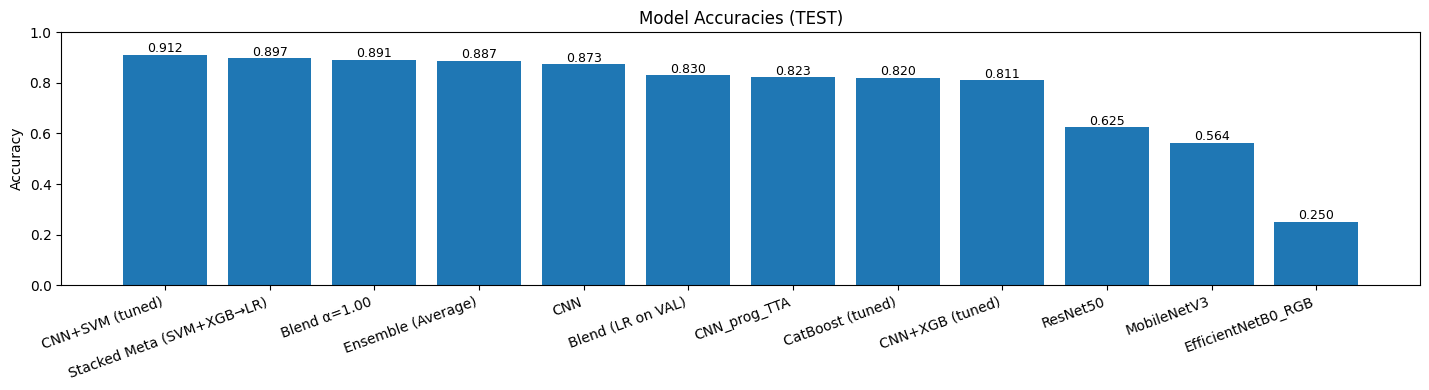

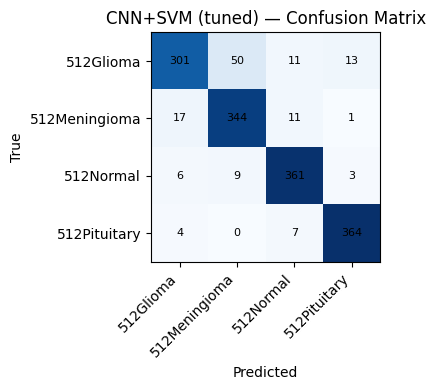

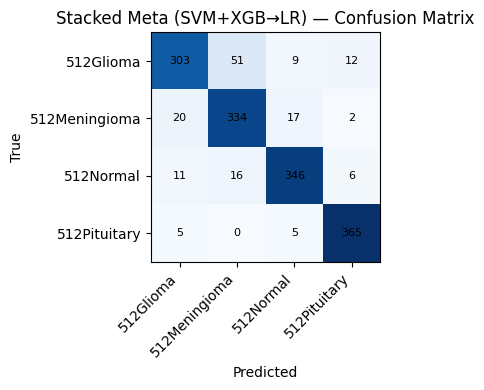

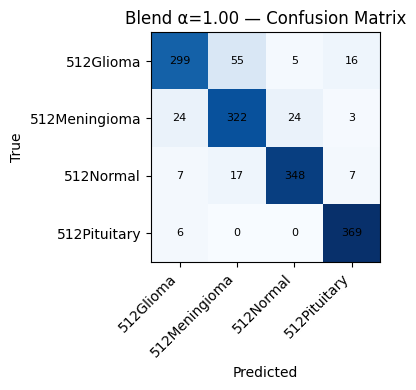

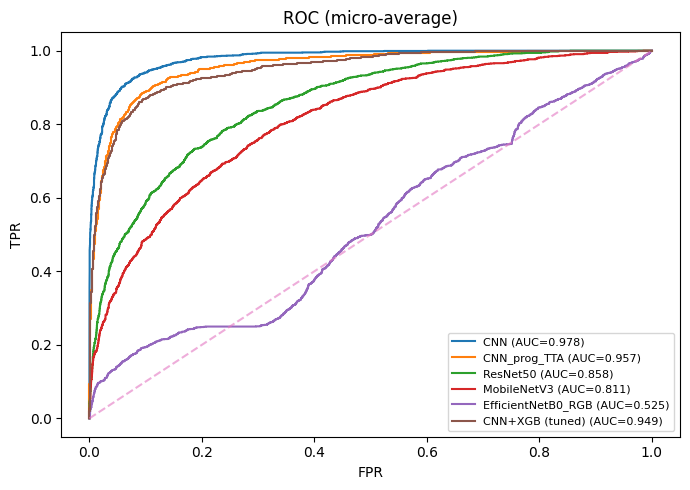

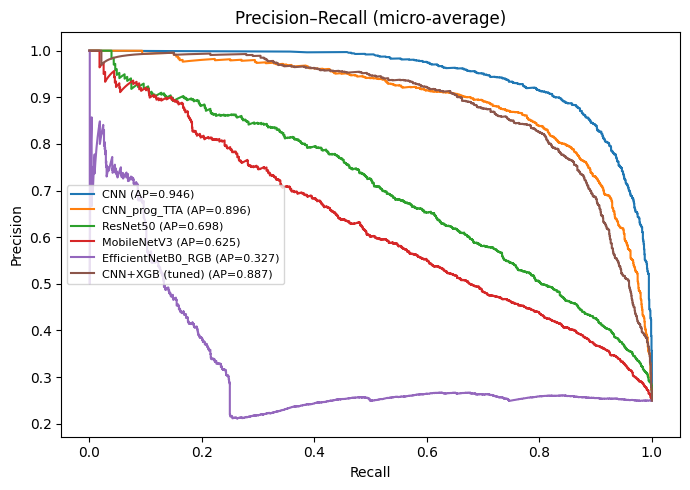

Saved: /content/drive/MyDrive/BrainMRI_Results/2025-09-01_20-10-25/models/cnn_gray.keras
Saved: /content/drive/MyDrive/BrainMRI_Results/2025-09-01_20-10-25/models/cnn_prog_gray_192.keras
Saved: /content/drive/MyDrive/BrainMRI_Results/2025-09-01_20-10-25/models/resnet50_rgb.keras
Saved: /content/drive/MyDrive/BrainMRI_Results/2025-09-01_20-10-25/models/mobilenetv3_rgb.keras
Saved: /content/drive/MyDrive/BrainMRI_Results/2025-09-01_20-10-25/models/EfficientNetB0_RGB.keras
Saved: XGB booster -> xgb_tuned.json
Saved: CatBoost -> catboost_tuned.cbm
Saved: svm_best.joblib
Saved: meta_blender_LR.joblib

✅ Done! All artifacts saved under: /content/drive/MyDrive/BrainMRI_Results/2025-09-01_20-10-25


In [71]:
# ======================= FINAL: Compare + Visualize + SAVE to Google Drive =======================
# This cell will:
#  1) Mount Drive and create a timestamped folder
#  2) Auto-discover models/results in your session
#  3) Produce metrics, plots, and save them + model artifacts to Drive
# ================================================================================================

import os, json, time, gc, numpy as np, matplotlib.pyplot as plt, itertools, joblib
from collections import OrderedDict
from datetime import datetime
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                             confusion_matrix, classification_report, roc_curve, auc,
                             precision_recall_curve)
from google.colab import drive

# ---------- Mount Drive & set save dir ----------
drive.mount('/content/drive')
RUN_TAG = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
BASE_DIR = f"/content/drive/MyDrive/BrainMRI_Results/{RUN_TAG}"
os.makedirs(BASE_DIR, exist_ok=True)
FIG_DIR = os.path.join(BASE_DIR, "figures"); os.makedirs(FIG_DIR, exist_ok=True)
NPY_DIR = os.path.join(BASE_DIR, "numpy");   os.makedirs(NPY_DIR, exist_ok=True)
MDL_DIR = os.path.join(BASE_DIR, "models");  os.makedirs(MDL_DIR, exist_ok=True)
TXT_DIR = os.path.join(BASE_DIR, "reports"); os.makedirs(TXT_DIR, exist_ok=True)
print("Saving to:", BASE_DIR)

# ---------- Helpers ----------
def stream_labels(ds):
    return np.concatenate([y for _, y in ds.as_numpy_iterator()], axis=0)

def stream_proba(model, ds):
    outs=[]
    for xb,_ in ds:
        outs.append(model.predict(xb, verbose=0))
    return np.concatenate(outs, axis=0)

def add_model(models, name, y_true, pred=None, proba=None):
    if proba is not None and pred is None:
        pred = np.argmax(proba, axis=1)
    if pred is None:
        return
    acc = accuracy_score(y_true, pred)
    f1m = f1_score(y_true, pred, average='macro', zero_division=0)
    prm = precision_score(y_true, pred, average='macro', zero_division=0)
    rcm = recall_score(y_true, pred, average='macro', zero_division=0)
    models[name] = {"pred": pred, "proba": proba, "acc": acc, "f1": f1m, "prec": prm, "rec": rcm}

def save_txt(path, text):
    with open(path, "w") as f: f.write(text)

def safe_class_names(n_classes):
    if 'class_names' in globals():
        return list(class_names)
    if 'le' in globals() and hasattr(le, 'classes_'):
        return list(le.classes_)
    return [f"Class {i}" for i in range(n_classes)]

# ---------- Ground truth + class names ----------
assert 'test_gray' in globals(), "Need test_gray dataset."
y_test = stream_labels(test_gray)
n_classes = int(y_test.max()) + 1
CLASSES = safe_class_names(n_classes)

# ---------- Collect models/results ----------
models = OrderedDict()

# 1) CNN variants
if 'cnn' in globals():
    try:
        P = stream_proba(cnn, test_gray)
        add_model(models, "CNN", y_test, proba=P)
        np.save(os.path.join(NPY_DIR, "cnn_proba.npy"), P)
    except Exception as e: print("CNN skipped:", e)

if 'cnn_prog' in globals():
    try:
        # prefer TTA outputs if you created them in previous cells
        if 'PROBA_CNN_TEST' in globals():
            add_model(models, "CNN_prog_TTA", y_test, proba=PROBA_CNN_TEST)
            np.save(os.path.join(NPY_DIR, "cnn_prog_tta_proba.npy"), PROBA_CNN_TEST)
        else:
            # need a matching one-hot test set to stream — rebuild quickly if needed
            if 'test_s2_oh' in globals():
                P = stream_proba(cnn_prog, test_s2_oh)
            else:
                # fallback: use raw test_gray (labels int); model expects 192x—assumes you used 192
                P = stream_proba(cnn_prog, test_gray)
            add_model(models, "CNN_prog", y_test, proba=P)
            np.save(os.path.join(NPY_DIR, "cnn_prog_proba.npy"), P)
    except Exception as e: print("CNN_prog skipped:", e)

# 2) RGB backbones (if present)
if 'resnet' in globals() and 'test_rgb' in globals():
    try:
        P = stream_proba(resnet, test_rgb)
        add_model(models, "ResNet50", y_test, proba=P)
        np.save(os.path.join(NPY_DIR, "resnet_proba.npy"), P)
    except Exception as e: print("ResNet skipped:", e)

if 'mbv3' in globals():
    try:
        ds = test_rgb_oh if 'test_rgb_oh' in globals() else test_rgb
        P = stream_proba(mbv3, ds)
        add_model(models, "MobileNetV3", y_test, proba=P)
        np.save(os.path.join(NPY_DIR, "mbv3_proba.npy"), P)
    except Exception as e: print("mbv3 skipped:", e)

if 'mbv3_hard' in globals():
    try:
        ds = test_rgb_oh if 'test_rgb_oh' in globals() else test_rgb
        P = stream_proba(mbv3_hard, ds)
        add_model(models, "MBV3+FocalMix", y_test, proba=P)
        np.save(os.path.join(NPY_DIR, "mbv3hard_proba.npy"), P)
    except Exception as e: print("mbv3_hard skipped:", e)

if 'third_model' in globals() and 'test_rgb' in globals():
    try:
        P = stream_proba(third_model, test_rgb)
        nm = third_model.name if hasattr(third_model, "name") else "ThirdModel"
        add_model(models, nm, y_test, proba=P)
        np.save(os.path.join(NPY_DIR, f"{nm}_proba.npy"), P)
    except Exception as e: print("third_model skipped:", e)

# 3) Feature-based learners
if 'XGB_TUNED' in globals():
    add_model(models, "CNN+XGB (tuned)", y_test, pred=XGB_TUNED.get("pred"), proba=XGB_TUNED.get("proba"))
    if XGB_TUNED.get("proba") is not None:
        np.save(os.path.join(NPY_DIR, "xgb_tuned_proba.npy"), XGB_TUNED["proba"])

if 'SVM_TUNED' in globals():
    add_model(models, "CNN+SVM (tuned)", y_test, pred=SVM_TUNED.get("pred"))
    np.save(os.path.join(NPY_DIR, "svm_tuned_pred.npy"), SVM_TUNED.get("pred"))

if 'BLEND' in globals():
    add_model(models, f"Blend α={BLEND.get('alpha',0):.2f}", y_test, pred=BLEND.get("pred"))

if 'BLEND_LR' in globals():
    add_model(models, "Blend (LR on VAL)", y_test, pred=BLEND_LR.get("pred"))

if 'CATBOOST_TUNED' in globals():
    add_model(models, "CatBoost (tuned)", y_test, pred=CATBOOST_TUNED.get("pred"))

# 4) Stacked meta (if you built it)
if 'meta' in globals() and 'X_meta_te' in globals():
    try:
        pred_meta = meta.predict(X_meta_te)
        proba_meta = meta.predict_proba(X_meta_te) if hasattr(meta, "predict_proba") else None
        add_model(models, "Stacked Meta (SVM+XGB→LR)", y_test, pred=pred_meta, proba=proba_meta)
        if proba_meta is not None:
            np.save(os.path.join(NPY_DIR, "stack_meta_proba.npy"), proba_meta)
    except Exception as e: print("Stacked meta skipped:", e)

# 5) Simple average if we have ≥2 proba models
proba_models = [(k, v["proba"]) for k, v in models.items() if v["proba"] is not None]
if len(proba_models) >= 2:
    P_avg = np.mean([P for _, P in proba_models], axis=0)
    add_model(models, "Ensemble (Average)", y_test, proba=P_avg)
    np.save(os.path.join(NPY_DIR, "ensemble_average_proba.npy"), P_avg)

# ---------- Build metrics table ----------
import pandas as pd
if not models:
    raise RuntimeError("No models detected to compare. Train/evaluate first.")

rows = []
for name, info in models.items():
    rows.append([name, info["acc"], info["f1"], info["prec"], info["rec"], int(info["proba"] is not None)])
summary_df = pd.DataFrame(rows, columns=["Model","Accuracy","F1 (macro)","Precision (macro)","Recall (macro)","Has_Proba"])
summary_df = summary_df.sort_values("Accuracy", ascending=False).reset_index(drop=True)
display(summary_df)
summary_path = os.path.join(BASE_DIR, "summary_metrics.csv")
summary_df.to_csv(summary_path, index=False)

# Save per-model classification reports & preds/probas
for name, info in models.items():
    rpt = classification_report(y_test, info["pred"], target_names=CLASSES, digits=4)
    save_txt(os.path.join(TXT_DIR, f"{name}_report.txt"), rpt)
    np.save(os.path.join(NPY_DIR, f"{name}_pred.npy"), info["pred"])
    if info["proba"] is not None:
        np.save(os.path.join(NPY_DIR, f"{name}_proba.npy"), info["proba"])

# ---------- Plots (and save) ----------
# Accuracy bar
plt.figure(figsize=(max(8, 1.2*len(summary_df)), 4))
plt.bar(summary_df["Model"], summary_df["Accuracy"])
for i, v in enumerate(summary_df["Accuracy"]):
    plt.text(i, v+0.01, f"{v:.3f}", ha='center', fontsize=9)
plt.ylim(0,1.0); plt.ylabel("Accuracy"); plt.title("Model Accuracies (TEST)")
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "accuracy_bar.png"), dpi=180)
plt.show()

# Top-3 confusion matrices
top3 = summary_df["Model"].tolist()[:3]
for name in top3:
    info = models[name]
    cm = confusion_matrix(y_test, info["pred"])
    plt.figure(figsize=(1.2*len(CLASSES), 1.0*len(CLASSES)))
    plt.imshow(cm, cmap='Blues')
    plt.title(f"{name} — Confusion Matrix"); plt.xlabel("Predicted"); plt.ylabel("True")
    plt.xticks(range(len(CLASSES)), CLASSES, rotation=45, ha='right')
    plt.yticks(range(len(CLASSES)), CLASSES)
    for (i, j) in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j], ha='center', va='center', fontsize=8)
    plt.tight_layout()
    fp = os.path.join(FIG_DIR, f"cm_{name}.png")
    plt.savefig(fp, dpi=180); plt.show()

# ROC & PR (micro-average) for models with probabilities
prob_models = [k for k,v in models.items() if v["proba"] is not None]
if prob_models:
    Y = np.zeros((y_test.shape[0], n_classes), dtype=int)
    Y[np.arange(y_test.shape[0]), y_test] = 1

    # ROC micro
    plt.figure(figsize=(7,5))
    for name in prob_models[:6]:  # limit for readability
        P = models[name]["proba"]
        fpr, tpr, _ = roc_curve(Y.ravel(), P.ravel())
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")
    plt.plot([0,1],[0,1],'--', alpha=0.6)
    plt.title("ROC (micro-average)"); plt.xlabel("FPR"); plt.ylabel("TPR")
    plt.legend(fontsize=8); plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, "roc_micro.png"), dpi=180)
    plt.show()

    # PR micro
    plt.figure(figsize=(7,5))
    for name in prob_models[:6]:
        P = models[name]["proba"]
        prec, rec, _ = precision_recall_curve(Y.ravel(), P.ravel())
        ap = auc(rec, prec)
        plt.plot(rec, prec, label=f"{name} (AP={ap:.3f})")
    plt.title("Precision–Recall (micro-average)"); plt.xlabel("Recall"); plt.ylabel("Precision")
    plt.legend(fontsize=8); plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, "pr_micro.png"), dpi=180)
    plt.show()

# ---------- Save models (if present) ----------
# Keras models
def save_keras(model, name):
    try:
        path = os.path.join(MDL_DIR, f"{name}.keras")
        model.save(path)
        print(f"Saved: {path}")
    except Exception as e:
        print(f"Save failed ({name}):", e)

if 'cnn' in globals():       save_keras(cnn, "cnn_gray")
if 'cnn_prog' in globals():  save_keras(cnn_prog, "cnn_prog_gray_192")
if 'resnet' in globals():    save_keras(resnet, "resnet50_rgb")
if 'mbv3' in globals():      save_keras(mbv3, "mobilenetv3_rgb")
if 'mbv3_hard' in globals(): save_keras(mbv3_hard, "mobilenetv3_focalmix_rgb")
if 'third_model' in globals(): save_keras(third_model, getattr(third_model, "name", "third_model"))

# XGBoost boosters (try typical variable names)
try:
    import xgboost as xgb
    if 'bst' in globals() and isinstance(bst, xgb.Booster):
        bst.save_model(os.path.join(MDL_DIR, "xgb_tuned.json"))
        print("Saved: XGB booster -> xgb_tuned.json")
except Exception as e:
    print("XGB save skipped:", e)

# CatBoost
try:
    from catboost import CatBoostClassifier
    if 'cat' in globals() and isinstance(cat, CatBoostClassifier):
        cat.save_model(os.path.join(MDL_DIR, "catboost_tuned.cbm"))
        print("Saved: CatBoost -> catboost_tuned.cbm")
except Exception as e:
    print("CatBoost save skipped:", e)

# SVM pipelines (svm_best or svm_clf)
try:
    if 'svm_best' in globals():
        joblib.dump(svm_best, os.path.join(MDL_DIR, "svm_best.joblib"))
        print("Saved: svm_best.joblib")
    elif 'svm_clf' in globals():
        joblib.dump(svm_clf, os.path.join(MDL_DIR, "svm_clf.joblib"))
        print("Saved: svm_clf.joblib")
except Exception as e:
    print("SVM save skipped:", e)

# Stacked/blender (LogisticRegression)
try:
    if 'meta' in globals():
        joblib.dump(meta, os.path.join(MDL_DIR, "meta_blender_LR.joblib"))
        print("Saved: meta_blender_LR.joblib")
except Exception as e:
    print("Meta save skipped:", e)

# Save a JSON with run metadata
meta_json = {
    "run_tag": RUN_TAG,
    "n_test": int(y_test.shape[0]),
    "classes": CLASSES,
    "models": list(models.keys()),
}
with open(os.path.join(BASE_DIR, "run_meta.json"), "w") as f:
    json.dump(meta_json, f, indent=2)

print("\n✅ Done! All artifacts saved under:", BASE_DIR)
gc.collect();
